
# Network Science - UDD

## Mesoestructura en redes complejas - Teoría


#### *Cristian Candia-Castro Vallejos, Ph.D.*

**Universidad del Desarrollo (UDD), Chile**

- Director at the [Computational Research in Social Sciences Laboratory (CRiSS-Lab)](http://criss-lab.com) 

- Faculty, Data Science Institute, School of Engineering


**Northwestern University, United States**

- External Faculty, Northwestern Institute on Complex Systems (NICO) Kellogg School of Management.


**Capybara Spa (AI & Network Science for Preventive, Traceable School Coexistence Compliance)**

- Founder & Chief Scientific and Technological Officer (CSTO) 

---

## **Para una versión interactiva complementaria de esta classe visita:**
 
 ### https://communities.criss-lab.com/

 ---


## Qué debe quedar claro 

1. Qué es mesoestructura y por qué importa.
2. Qué significa detectar comunidades.
3. Qué hace modularidad y qué no hace.
4. Cómo se comparan los algoritmos principales.
5. Qué límites interpretativos son ineludibles.
6. Cómo trasladar estos conceptos a compras públicas sin sobre-reclamar.


## Literatura base usada aquí

La columna vertebral conceptual es:

- **Newman (2006)**, *Modularity and community structure in networks*.
- **Newman, Networks**, especialmente capítulos sobre groups of vertices, modularity, spectral ideas, `k-core` y equivalencia estructural.
- **Barabási**, para intuiciones de organización modular y lectura estructural aplicada.
- **Latapy, Magnien y Del Vecchio (2008)** para la advertencia crítica sobre redes bipartitas y proyecciones, que será central al pasar a compras públicas.


## Cómo leer este notebook

La secuencia está pensada en tres movimientos:

1. **Conceptualizar**: comunidades, núcleo-periferia y roles.
2. **Formalizar**: modularidad, modularity matrix, algoritmos, estabilidad y resolución.
3. **Traducir**: hipótesis sustantivas prudentes para compras públicas.

La práctica queda en:

- `Lab_5_Practica_Redes_Tradicionales.ipynb`
- `Lab_5_Practica_Compras_Publicas.ipynb`
---

## 1. ¿Por qué mirar mesoestructura?

En análisis de redes solemos movernos entre tres escalas:

- **Micro**: nodos, atributos, vecindades inmediatas.
- **Meso**: comunidades, núcleos, puentes, subestructuras intermedias.
- **Macro**: conectividad global, componentes, densidad, distribuciones agregadas.

La mesoestructura importa porque muchas preguntas sustantivas viven ahí:

- ¿qué subconjuntos parecen formar módulos/clusters?
- ¿qué actores están más embebidos?
- ¿quién conecta segmentos?
- ¿qué patrones permiten segmentación o hipótesis de dependencia?


In [51]:
import time # para medir tiempos de ejecución
import warnings # for ignoring warnings in the notebook
from itertools import combinations, islice # para iterar sobre combinaciones de nodos y para limitar iteraciones

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try: # para configurar seaborn si está disponible y evitar errores si no lo está (que no es un requisito para el curso)
    import seaborn as sns
    if hasattr(sns, "set_theme"):
        sns.set_theme(style="whitegrid", context="talk")
    else:
        sns.set_style("whitegrid")
        sns.set_context("talk")
except Exception:
    sns = None

try: # para configurar display de IPython si está disponible y evitar errores si no lo está (que no es un requisito para el curso)
    from IPython.display import display
except Exception:
    def display(obj):
        print(obj)

warnings.filterwarnings("ignore")# para evitar warnings que pueden ser molestos en el notebook
np.random.seed(42) # para asegurar reproducibilidad de resultados aleatorios
plt.rcParams["figure.figsize"] = (10, 7) # para configurar tamaño de figuras
plt.rcParams["axes.spines.top"] = False # para configurar estilo de gráficos
plt.rcParams["axes.spines.right"] = False # para configurar estilo de gráficos


In [7]:
# Si hace falta instalar dependencias:
# !pip install python-louvain scikit-learn

In [ ]:
from community import community_louvain
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

SKLEARN_OK = True 


def partition_to_communities(partition): # convierte un diccionario de nodo->grupo a una lista de conjuntos de nodos por comunidad
    groups = {}
    for node, group in partition.items():
        groups.setdefault(group, set()).add(node)
    return list(groups.values())


def communities_to_partition(communities):# convierte una lista de conjuntos de nodos por comunidad a un diccionario de nodo->grupo
    partition = {}
    for idx, community in enumerate(communities):
        for node in community:
            partition[node] = idx
    return partition


def partition_modularity(G, partition, weight=None):# calcula la modularidad de una partición dada un grafo y un diccionario de nodo->grupo
    communities = partition_to_communities(partition)
    return nx.algorithms.community.quality.modularity(G, communities, weight=weight)


# Evalúa qué tan similar es la partición detectada por el algoritmo
# respecto de etiquetas externas ("ground truth") disponibles para los nodos.
#
# Métricas:
# - ARI (Adjusted Rand Index):
#   compara ambas particiones mirando pares de nodos y corrige por azar.
#   ARI = 1 indica coincidencia perfecta; ARI ≈ 0 indica acuerdo similar al azar.
#   El acuerdo por azar en ARI se calcula como el número esperado de pares de nodos 
#   que coincidirían en ambas particiones si los nodos se distribuyeran aleatoriamente 
#   en grupos del mismo tamaño que los observados. Por eso ARI no premia coincidencias 
#   triviales debidas solo a la estructura de tamaños.
#
# - NMI (Normalized Mutual Information):
#   mide cuánta información comparte la partición predicha con la partición externa, o 
#   cuánta información comparten dos particiones.
#   Se calcula a partir de la información mutua entre ambas y luego se normaliza usando 
#   sus entropías, de modo que el resultado quede típicamente entre 0 y 1. Entonces NMI 
#   compara la información compartida con la cantidad total de información contenida en 
#   ambas particiones.
#   NMI = 1 indica coincidencia perfecta; NMI = 0 indica que no comparten información.
#
# Importante:
# estas métricas comparan agrupamientos, no los nombres de las etiquetas.
# Por ejemplo, si una partición usa {0,1} y otra usa {5,9}, pero agrupan igual
# a los nodos, ARI y NMI serán altos.
#
# Advertencia:
# un valor bajo no siempre implica una "mala" comunidad en términos estructurales;
# también puede ocurrir que las etiquetas externas no coincidan con la mesoestructura
# real de la red.
# En otras palabras: sirven para evaluar "qué tan parecida" es la comunidad detectada
# a una clasificación externa conocida.
def evaluate_partition(external_labels, predicted_partition):
    if external_labels is None or not SKLEARN_OK:
        return {"ARI": np.nan, "NMI": np.nan}
    nodes = sorted(predicted_partition)
    y_true = [external_labels[n] for n in nodes]
    y_pred = [predicted_partition[n] for n in nodes]
    return {
        "ARI": adjusted_rand_score(y_true, y_pred),
        "NMI": normalized_mutual_info_score(y_true, y_pred),
    }


# Evalúa la concordancia promedio entre múltiples particiones alternativas de la misma red.
#
# Aunque ARI y NMI suelen usarse para comparar una partición detectada con etiquetas
# externas conocidas, también pueden usarse para comparar directamente dos particiones
# cualquiera. Aquí se usan en ese segundo sentido.
#
# Para cada par de particiones calcula:
# - ARI (Adjusted Rand Index): acuerdo entre agrupamientos corrigiendo por azar.
# - NMI (Normalized Mutual Information): información compartida entre agrupamientos.
#
# Luego promedia esos valores sobre todos los pares de particiones.
#
# Interpretación:
# valores altos de mean_ARI y mean_NMI indican que las soluciones son similares entre sí,
# es decir, que la estructura detectada es relativamente estable. Valores bajos sugieren
# inestabilidad o sensibilidad a la semilla aleatoria, al algoritmo o a sus parámetros.
#
# Nota:
# esta función no evalúa "exactitud" respecto de una verdad externa; evalúa reproducibilidad
# o consistencia interna entre particiones alternativas.
def pairwise_agreement(partitions):
    if not SKLEARN_OK or len(partitions) < 2:
        return {"mean_ARI": np.nan, "mean_NMI": np.nan}
    nodes = sorted(partitions[0])
    aris, nmis = [], []
    for p1, p2 in combinations(partitions, 2):
        y1 = [p1[n] for n in nodes]
        y2 = [p2[n] for n in nodes]
        aris.append(adjusted_rand_score(y1, y2))
        nmis.append(normalized_mutual_info_score(y1, y2))
    return {"mean_ARI": float(np.mean(aris)), "mean_NMI": float(np.mean(nmis))}



# Construye una matriz de co-asignación (o consensus matrix) a partir de varias particiones.
#
# Cada entrada M[i, j] indica la fracción de particiones en las que los nodos i y j
# quedaron asignados a la misma comunidad.
#
# Interpretación:
# - M[i, j] = 1   -> siempre juntos
# - M[i, j] = 0   -> nunca juntos
# - valores intermedios -> asignación inestable o ambigua
#
# Esta matriz es útil para:
# - evaluar robustez de comunidades,
# - detectar núcleos estables de nodos,
# - construir particiones de consenso.
#
# Nota:
# el orden de `nodes` define el orden de filas y columnas de la matriz.
def coassignment_matrix(partitions, nodes):
    M = np.zeros((len(nodes), len(nodes)), dtype=float)
    for part in partitions:
        labels = np.array([part[n] for n in nodes])
        M += (labels[:, None] == labels[None, :]).astype(float)
    return M / len(partitions)


def run_louvain(G, seed=42, resolution=1.0, weight=None): # ejecuta el algoritmo de Louvain para detección de comunidades
    effective_weight = "weight" if weight is None else weight
    return community_louvain.best_partition(
        G, random_state=seed, resolution=resolution, weight=effective_weight
    )


def run_label_propagation(G, seed=42, weight=None): # ejecuta el algoritmo de Label Propagation para detección de comunidades
    try:
        comms = list(nx.algorithms.community.asyn_lpa_communities(G, weight=weight, seed=seed))
    except TypeError:
        comms = list(nx.algorithms.community.asyn_lpa_communities(G, weight=weight))
    return communities_to_partition(comms)


def run_greedy_modularity(G, weight=None): # ejecuta el algoritmo de Greedy Modularity para detección de comunidades
    comms = list(nx.algorithms.community.greedy_modularity_communities(G, weight=weight))
    return communities_to_partition(comms)

# construye la matriz de modularidad B = A - P, donde P es la matriz de null model de configuración (P[i, j] = k_i * k_j / (2m))
def modularity_matrix(G, weight=None): 
    nodes = list(G.nodes())
    A = nx.to_numpy_array(G, nodelist=nodes, weight=weight)
    k = A.sum(axis=1)
    m = A.sum() / 2.0
    B = A - np.outer(k, k) / (2.0 * m) # B[i, j] = A[i, j] - (k[i] * k[j]) / (2m); outer construye todos los productos k[i] * k[j] de forma eficiente
    return B, nodes



# Realiza una bipartición espectral usando la matriz de modularidad.
#
# Idea:
# la matriz de modularidad B compara enlaces observados con enlaces esperados
# bajo un null model que preserva grados. Su autovector principal define una
# dirección que aproxima la mejor división binaria de la red en términos de modularidad.
#
# Regla de partición:
# - componentes positivas del autovector principal -> comunidad 1
# - componentes negativas -> comunidad 0
#
# Si el autovector no cambia de signo, se fuerza una partición en dos mitades
# según el orden de sus componentes como criterio práctico.
#
# Devuelve:
# - part: partición nodo -> {0,1}
# - lead_val: autovalor principal de B
# - lead_vec: autovector principal
# - nodes: orden de nodos usado para construir B
#
# Nota:
# en la formulación clásica, una división solo es sustantivamente interpretable
# si el autovalor principal es positivo.
def run_spectral_bipartition(G, weight=None):
    B, nodes = modularity_matrix(G, weight=weight)
    eigvals, eigvecs = np.linalg.eigh(B)
    idx = int(np.argmax(eigvals))
    lead_val = float(eigvals[idx])
    lead_vec = eigvecs[:, idx]
    part = {}
    if np.all(lead_vec >= 0) or np.all(lead_vec <= 0):
        order = np.argsort(lead_vec)
        left = set(order[: len(nodes) // 2])
        for i, node in enumerate(nodes):
            part[node] = 0 if i in left else 1
    else:
        for i, node in enumerate(nodes):
            part[node] = 1 if lead_vec[i] >= 0 else 0
    return part, lead_val, lead_vec, nodes



 # ejecuta el algoritmo de Girvan-Newman para detección de comunidades y 
 # devuelve la partición con mejor modularidad entre las primeras `max_levels` divisiones
def run_girvan_newman_best(G, weight=None, max_levels=8):
    generator = nx.algorithms.community.girvan_newman(G)
    best_partition = None
    best_Q = -1.0
    best_k = None
    for communities in islice(generator, max_levels):
        part = communities_to_partition(communities)
        Q = partition_modularity(G, part, weight=weight)
        if Q > best_Q:
            best_partition = part
            best_Q = Q
            best_k = len(set(part.values()))
    return best_partition, best_Q, best_k



# ejecuta una suite de métodos de detección de comunidades en el grafo G, 
# evalúa cada partición obtenida y devuelve un DataFrame con los resultados 
# y un diccionario con las particiones.
def run_method_suite(G, external_labels=None, weight=None, seed=42): 
    methods = [
        "spectral_bipartition",
        "girvan_newman",
        "greedy_modularity",
        "label_propagation",
        "louvain",
    ]
    rows = []
    partitions = {}
    for method in methods:
        start = time.perf_counter()
        extra = {}
        if method == "spectral_bipartition":
            part, lead_val, _, _ = run_spectral_bipartition(G, weight=weight)
            extra["lead_eigenvalue"] = lead_val
        elif method == "girvan_newman":
            part, best_Q, best_k = run_girvan_newman_best(G, weight=weight, max_levels=8)
            extra["gn_best_level_k"] = best_k
        elif method == "greedy_modularity":
            part = run_greedy_modularity(G, weight=weight)
        elif method == "label_propagation":
            part = run_label_propagation(G, seed=seed, weight=weight)
        elif method == "louvain":
            part = run_louvain(G, seed=seed, resolution=1.0, weight=weight)
        row = {
            "method": method,
            "n_communities": len(set(part.values())),
            "largest_community": pd.Series(part).value_counts().max(),
            "modularity": partition_modularity(G, part, weight=weight),
            "runtime_sec": time.perf_counter() - start,
        }
        row.update(evaluate_partition(external_labels, part))
        row.update(extra)
        rows.append(row)
        partitions[method] = part
    return pd.DataFrame(rows), partitions


# Función para graficar la partición en un eje dado con colores por comunidad. 
# Permite mostrar etiquetas de nodos y ajustar el tamaño de los nodos.
def plot_partition_on_axis(ax, G, pos, partition, title, labels=False, node_scale=1.0):
    groups = sorted(set(partition.values()))
    cmap = plt.cm.get_cmap("tab10", max(len(groups), 3))
    colors = {g: cmap(i) for i, g in enumerate(groups)}
    node_colors = [colors[partition[n]] for n in G.nodes()]
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.25, width=0.8, edge_color="gray")
    nx.draw_networkx_nodes(
        G,
        pos,
        node_color=node_colors,
        node_size=(420 if G.number_of_nodes() <= 40 else 90) * node_scale,
        linewidths=0.5,
        edgecolors="white",
        ax=ax,
    )
    if labels:
        nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
    ax.set_title(title)
    ax.axis("off")


### Tres escalas de análisis de una red

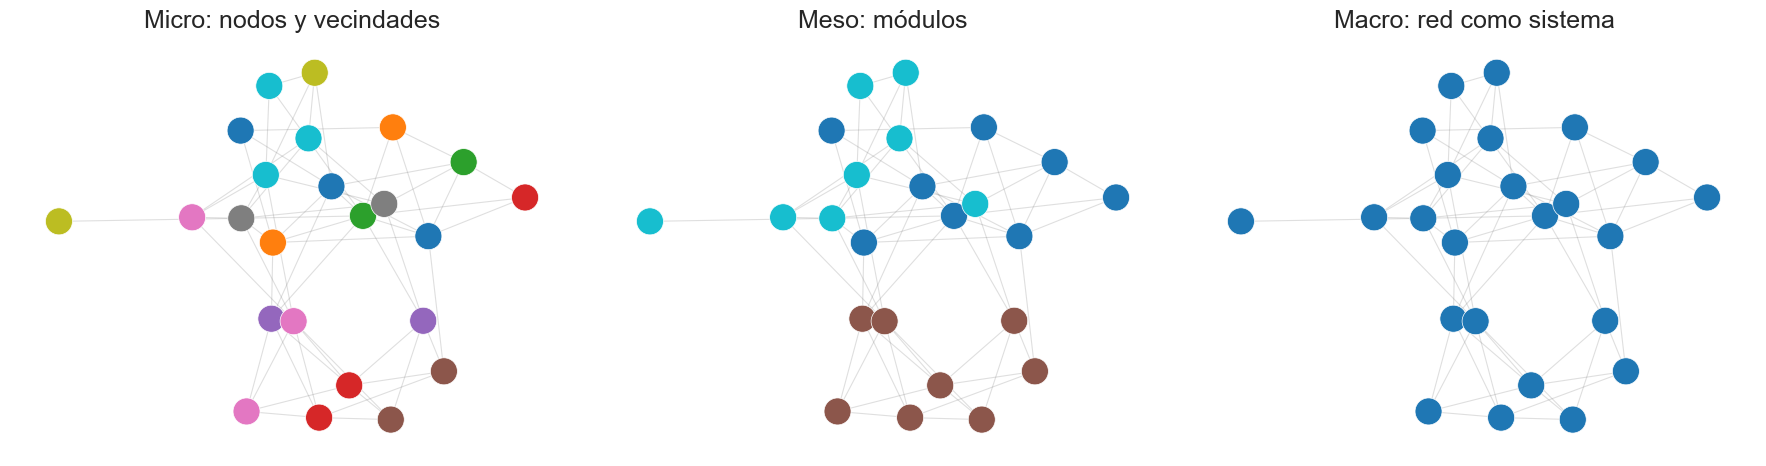

In [ ]:
# Parámetros del modelo de bloques estocásticos
sizes = [8, 8, 8]
P = [
    [0.55, 0.04, 0.03],
    [0.04, 0.50, 0.05],
    [0.03, 0.05, 0.45],
]
G_scale = nx.stochastic_block_model(sizes, P, seed=42) # genera un grafo sintético con estructura de bloques usando el modelo de bloques estocásticos
pos_scale = nx.spring_layout(G_scale, seed=42)
block_map = {}
start = 0
for b, size in enumerate(sizes):
    for n in range(start, start + size):
        block_map[n] = b
    start += size
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
plot_partition_on_axis(axes[0], G_scale, pos_scale, {n: n for n in G_scale.nodes()}, "Micro: nodos y vecindades", labels=False, node_scale=0.9)
plot_partition_on_axis(axes[1], G_scale, pos_scale, block_map, "Meso: módulos", labels=False, node_scale=0.9)
plot_partition_on_axis(axes[2], G_scale, pos_scale, {n: 0 for n in G_scale.nodes()}, "Macro: red como sistema", labels=False, node_scale=0.9)
plt.tight_layout()
plt.show()


## 2. ¿Qué entendemos por mesoestructura?

Para esta clase conviene separar tres familias de patrones:

### Comunidades
Grupos con relativamente más densidad interna de la esperada o relativamente menos vínculos externos.

### Core–periphery
Organización en la que existe un subconjunto más embebido o centralmente conectado y una periferia menos cohesionada.

### Roles estructurales
Posiciones o funciones relacionales: puentes, hubs locales, nodos frontera, periféricos especializados, etc.


## 3. No confundir comunidad, núcleo y rol

- Un nodo puede estar en una comunidad clara y no pertenecer al núcleo.
- Un nodo puede pertenecer al núcleo y no ser puente.
- Un rol estructural no es una comunidad; es una posición relacional.

Esta distinción es clave porque distintos algoritmos capturan cosas distintas. No existe una sola “mesoestructura verdadera” comprimida en un output único.


## 4. Detectar comunidades: el problema no es trivial

Detectar comunidades no es simplemente “dejar que un algoritmo encuentre grupos”. Es un problema conceptualmente abierto, porque una comunidad no tiene una definición única y porque distintas decisiones metodológicas pueden producir particiones diferentes pero igualmente razonables.

**Primero, no existe una definición universal de comunidad.**
Algunos métodos buscan grupos con alta densidad interna y pocas conexiones externas. Otros buscan nodos con patrones de conexión similares, o particiones que se separen bien respecto de un modelo nulo, o bloques que expliquen probabilísticamente la red. Por eso, distintos algoritmos pueden estar resolviendo problemas distintos aunque todos hablen de “comunidades”.

**Segundo, la estructura puede ser multiescala.**
En una misma red pueden coexistir grupos pequeños, módulos intermedios y bloques más grandes. No siempre hay una única partición correcta: distintas resoluciones pueden capturar niveles distintos, pero reales, de organización. Una partición fina puede mostrar subgrupos locales; una más gruesa puede mostrar grandes divisiones funcionales.

**Tercero, la representación de la red importa.**
Las comunidades detectadas dependen de cómo construimos la red: si usamos pesos o binarizamos, si tratamos la red como dirigida o no dirigida, si proyectamos una bipartita, o si agregamos interacciones temporales en una sola capa. La mesoestructura no es independiente del modelamiento: también refleja decisiones analíticas previas.

**Cuarto, los algoritmos optimizan criterios distintos.**
Louvain o Leiden maximizan modularidad; métodos espectrales usan propiedades algebraicas de matrices como el Laplaciano o la matriz de modularidad; los stochastic block models buscan la mejor explicación probabilística de la estructura. Entonces, si dos métodos entregan resultados distintos, eso no implica automáticamente que uno esté bien y el otro mal: puede significar que están privilegiando patrones distintos.

**Quinto, la validación tampoco es trivial.**
Si existen etiquetas externas, métricas como ARI o NMI permiten comparar particiones. Pero incluso ahí hay que ser cuidadosos: una partición puede tener bajo acuerdo con las etiquetas externas y aun así capturar una estructura relacional sustantivamente relevante. Las etiquetas externas no siempre coinciden con la mesoestructura de la red.

Por eso, cuando dos algoritmos entregan particiones distintas, la pregunta correcta no es **“cuál descubrió la verdad”**, sino: **qué definición de comunidad usa cada uno, qué escala captura, qué supuestos incorpora y qué estructura privilegia**. 

**Detectar comunidades no es revelar una única partición escondida en los datos, sino extraer una lectura mesoestructural bajo ciertos criterios formales y decisiones de modelamiento.**

## 5. Teoría de comunidades: intuición inicial

La intuición más extendida sobre una comunidad es simple: **un grupo de nodos más conectados entre sí que con el resto de la red**. En términos informales:

* dentro de una comunidad hay relativamente muchos enlaces;
* entre comunidades hay relativamente pocos.

Esa intuición es útil como punto de partida, pero todavía es incompleta. El problema es la palabra **“relativamente”**: muchos, ¿respecto de qué?

Si una red tiene nodos de alto grado, o una distribución de grados muy heterogénea, ciertos grupos pueden concentrar muchos enlaces internos simplemente porque sus nodos ya tienden a conectarse mucho con todo. En ese caso, observar alta densidad interna no basta para concluir que existe una comunidad sustantiva: parte de esa cohesión podría explicarse solo por la estructura de grados.

Por eso, en detección de comunidades no basta con contar enlaces internos. Lo importante es comparar lo observado con algún **patrón de referencia** o **modelo nulo**. La pregunta relevante no es solo:

> ¿hay muchos enlaces dentro del grupo?

sino más bien:

> ¿hay más enlaces internos de los que esperaríamos dada la estructura básica de la red?

Esta idea es central en enfoques como la **modularidad**, donde una comunidad no se define solo por tener cohesión interna, sino por tener **más cohesión interna que la esperada bajo un modelo aleatorio comparable**.

En otras palabras, una comunidad no es simplemente un grupo denso, sino un grupo cuya densidad interna resulta **sorprendente** respecto de una línea base adecuada. Esa es la transición desde la intuición informal hacia una formulación más rigurosa del problema.


<div style="text-align:center;">
  <img src="assets/newman2006_fig1_communities.jpg" width="520">
</div>

**Figura:** intuición visual clásica de comunidades como grupos densos con pocos enlaces entre grupos.  
**Fuente:** Newman (2006), *Modularity and community structure in networks*.


## 6. La lógica de modularidad

Newman formaliza la calidad de una partición con:

$$
Q = \frac{1}{2m}\sum_{ij}\left(A_{ij} - \frac{k_i k_j}{2m}\right)\delta(c_i,c_j)
$$

donde:

- $A_{ij}$ es la matriz de adyacencia;
- $k_i$ y $k_j$ son grados;
- $m$ es el número total de aristas;
- $\delta(c_i,c_j)$ vale 1 si ambos nodos quedan en la misma comunidad.

Interpretación:

- $A_{ij}$ captura lo observado;
- $k_i k_j / 2m$ captura lo esperado bajo un nulo de grados;
- el término entre paréntesis mide exceso o déficit de conexión;
- la suma se restringe a pares ubicados en la misma comunidad.



La idea central es esta: una partición tendrá **modularidad alta** si, dentro de las comunidades propuestas, observamos **más enlaces de los que esperaríamos por azar** dado el grado de los nodos.

### Casos límite para fijar intuición

**Caso 1: un par de nodos del mismo grupo está conectado y además esa conexión era poco esperable.**
Entonces:

* $A_{ij}=1$,
* $\frac{k_i k_j}{2m}$ es pequeño,
* por tanto $\left(A_{ij} - \frac{k_i k_j}{2m}\right) > 0$.

Ese par **aporta positivamente** a (Q).
Intuición: el algoritmo “premia” haber puesto juntos dos nodos cuya conexión interna resulta más fuerte de lo esperable.

**Caso 2: un par de nodos del mismo grupo no está conectado, pero según el modelo nulo sería esperable que sí lo estuviera.**
Entonces:

* $A_{ij}=0$,
* $\frac{k_i k_j}{2m}$ es relativamente grande,
* por tanto $\left(A_{ij} - \frac{k_i k_j}{2m}\right) < 0$.

Ese par **resta** modularidad.
Intuición: el algoritmo “castiga” poner en la misma comunidad nodos que, si realmente formaran un bloque cohesionado, uno habría esperado ver conectados.

**Caso 3: todos los nodos se ponen en una sola comunidad.**
En ese caso, $\delta(c_i,c_j)=1$ para todos los pares. Entonces la suma corre sobre toda la red. Pero la modularidad está construida justamente para comparar observado y esperado globalmente, y esos términos se compensan, de modo que:

$$
Q \approx 0
$$

(en la formulación estándar, exactamente 0 bajo la suma total apropiada).
Intuición: decir que “toda la red es una sola comunidad” no revela ninguna mesoestructura.

**Caso 4: cada nodo queda en su propia comunidad.**
Aquí casi no hay pares de nodos distintos con $\delta(c_i,c_j)=1$, así que no se acumula estructura interna significativa. Esta partición también da una modularidad muy baja, típicamente cercana a:

$$
Q \approx 0
$$

o incluso negativa según la convención diagonal. Si cada nodo queda en su propia comunidad, la modularidad es muy baja. En la formulación estándar que incluye los términos diagonales $i=j$, puede ser incluso negativa, porque no hay estructura interna entre nodos distintos y solo permanecen términos esperados negativos asociados a la diagonal ($A_{ii}=0$, pero $\delta(c_i,c_i)=1$, entonces $Q=-\frac{1}{(2m)^2}\sum_i k_i^2$).

Intuición: fragmentar completamente la red tampoco captura comunidades.

**Caso 5: un grupo tiene muchos enlaces internos, pero eso ya era esperable por sus grados altos.**
Aunque ($A_{ij}=1$) para muchos pares, también puede ser grande el término esperado ($\frac{k_i k_j}{2m}$). Entonces el exceso real puede ser pequeño.
Intuición: modularidad **no premia densidad bruta**, sino **densidad interna por sobre lo esperable dado el grado**.

**Caso 6: un grupo pequeño está muy bien conectado internamente, pero la partición global lo fusiona con otro bloque.**
La modularidad puede preferir fusionar bloques si eso mejora el valor global de (Q).
Intuición: esta es una pista del conocido **resolution limit**: comunidades pequeñas pero reales pueden pasar desapercibidas si se optimiza solo modularidad global.

### Lectura conceptual

Así, la modularidad no pregunta simplemente:

> “¿hay muchos enlaces dentro de este grupo?”

sino:

> “¿hay más enlaces dentro de este grupo de los que esperaríamos si la red solo estuviera organizada por grados?”

Esa diferencia es clave. Una comunidad, bajo esta lógica, no es solo un grupo denso, sino un grupo cuya cohesión interna resulta **sorprendente respecto de un nulo estructuralmente razonable**.

### Qué compara modularidad, exactamente

Modularidad no compara una comunidad con “cualquier grupo aleatorio” de forma vaga. Compara una partición contra una red de referencia en la que los grados importan.

Si no entiendes el nulo, no entiendes qué significa un valor alto de `Q`.


### Qué modularidad sí y no puede decir

Sí puede decir:

- que cierta partición produce exceso de densidad interna respecto del nulo
- que una red parece modular a cierta escala
- que unas particiones son mejores que otras bajo ese criterio

No puede decir por sí sola:

- que la partición sea única
- que haya descubierto categorías "reales"
- que identifique mecanismo causal


{'A': ['A1', 'A2', 'A3', 'A4', 'A5'], 'B': ['B1', 'B2', 'B3', 'B4', 'B5'], 'C': ['C1', 'C2', 'C3', 'C4', 'C5']}


,partition,Q
1,tres módulos naturales,0.5758
0,todo junto,0.0000
2,asignación artificial,-0.1515


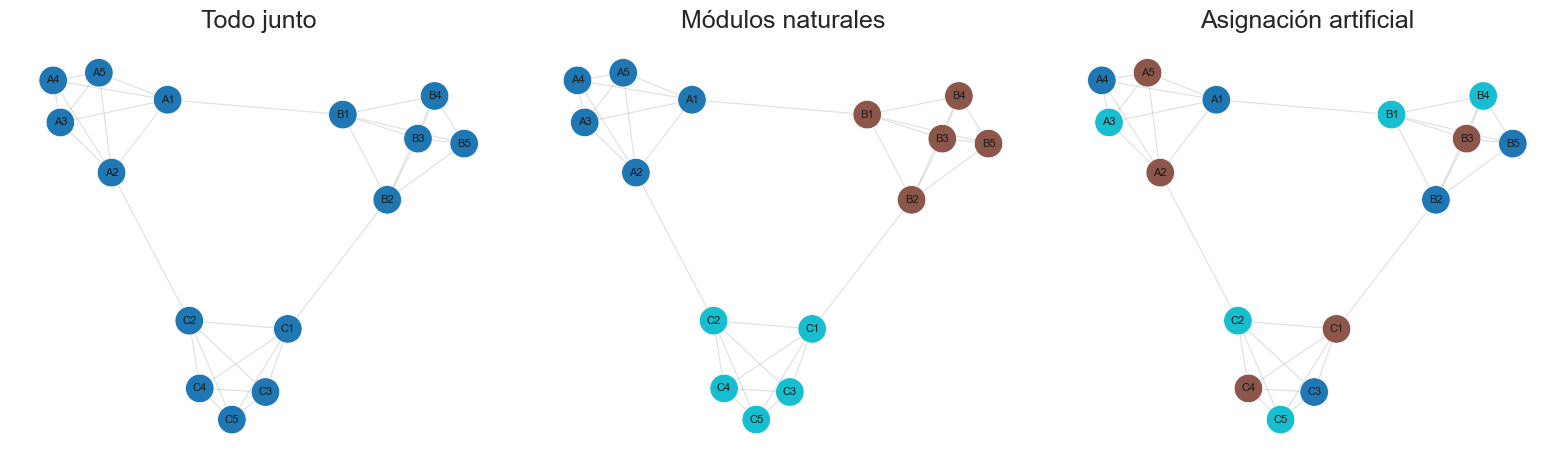

In [23]:
G_toy = nx.Graph()
cliques = { # tres cliques completos de 5 nodos cada uno, con algunas conexiones entre ellos
    "A": [f"A{i}" for i in range(1, 6)],
    "B": [f"B{i}" for i in range(1, 6)],
    "C": [f"C{i}" for i in range(1, 6)],
}
print(cliques)

for nodes in cliques.values(): # cada bloque es un clique completo de 5 nodos 
    G_toy.add_nodes_from(nodes)
    for i, u in enumerate(nodes):
        for v in nodes[i + 1:]:
            G_toy.add_edge(u, v)

G_toy.add_edges_from([("A1", "B1"), ("B2", "C1"), ("A2", "C2")]) # conexiones entre bloques para hacer el caso más interesante

toy_pos = nx.spring_layout(G_toy, seed=42)
p_all = {n: 0 for n in G_toy.nodes()} # todos los nodos en la misma comunidad
p_nat = {n: {"A": 0, "B": 1, "C": 2}[n[0]] for n in G_toy.nodes()} # partición que refleja los cliques naturales
p_rand = {n: i % 3 for i, n in enumerate(sorted(G_toy.nodes()))} # asignación aleatoria de nodos a 3 grupos, sin relación con la estructura real
toy_df = pd.DataFrame([
    {"partition": "todo junto", "Q": partition_modularity(G_toy, p_all)},
    {"partition": "tres módulos naturales", "Q": partition_modularity(G_toy, p_nat)},
    {"partition": "asignación artificial", "Q": partition_modularity(G_toy, p_rand)},
]).sort_values("Q", ascending=False)

display(toy_df.style.format({"Q": "{:.4f}"}))
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_partition_on_axis(axes[0], G_toy, toy_pos, p_all, "Todo junto", labels=True)
plot_partition_on_axis(axes[1], G_toy, toy_pos, p_nat, "Módulos naturales", labels=True)
plot_partition_on_axis(axes[2], G_toy, toy_pos, p_rand, "Asignación artificial", labels=True)
plt.tight_layout()
plt.show()


## 7. La *modularity matrix* y la lógica espectral

Newman reescribe la modularidad en términos de la **matriz de modularidad**:

$$
B_{ij} = A_{ij} - \frac{k_i k_j}{2m}
$$

Esta matriz compara, para cada par de nodos, lo **observado** con lo **esperado** bajo un modelo nulo que preserva grados:

* si $B_{ij} > 0$, el par está más conectado de lo esperable;
* si $B_{ij} < 0$, está menos conectado de lo esperable;
* si $B_{ij} \approx 0$, su relación no se aparta mucho del nulo.

La ventaja de esta formulación es que transforma el problema de detectar comunidades en un problema algebraico: buscar una partición que agrupe nodos de modo que, dentro de los grupos, se acumulen valores positivos de (B) y se eviten valores negativos.

### La intuición espectral

La lógica espectral consiste en mirar los **autovalores** y **autovectores** de (B). La idea es la siguiente:

* si la red no tuviera mesoestructura clara más allá de la explicada por los grados, no habría una dirección dominante de desviación respecto del nulo
* si sí existe una estructura comunitaria relevante, esa desviación tiende a organizarse en una dirección principal
* esa dirección queda capturada por el **autovector principal** de la matriz de modularidad

Por eso, el autovector asociado al mayor autovalor positivo entrega una guía para construir una bipartición informativa: nodos con componentes de signo similar tienden a quedar en el mismo lado del corte, porque contribuyen de forma parecida a la desviación respecto del modelo nulo. Newman muestra precisamente que la modularidad puede expresarse en términos espectrales de esta matriz y que eso permite derivar un algoritmo de detección de comunidades. 

### Intuición operativa

En términos simples:

* la matriz (B) mide **dónde la red excede o no excede lo esperado**;
* el autovector principal resume el **patrón dominante de ese exceso**;
* usar su signo para separar nodos produce una primera aproximación a una partición con alta modularidad.

Así, el enfoque espectral no busca comunidades contando enlaces de manera local, sino identificando la **dirección global más fuerte en que la red se aleja del azar estructurado por grados**.


,eigenvalue
lambda_1,3.8737
lambda_2,3.8737
lambda_3,0.0000
lambda_4,-0.1497
lambda_5,-0.1497


Mayor eigenvalue de B: 3.8737
Q de la bipartición espectral: 0.3838


,node,eigenvector_value,group
2,A3,-0.368484,0
3,A4,-0.368484,0
4,A5,-0.368484,0
0,A1,-0.354324,0
1,A2,-0.336103,0
5,B1,0.069008,1
7,B3,0.141709,1
8,B4,0.141709,1
9,B5,0.141709,1
11,C2,0.157812,1


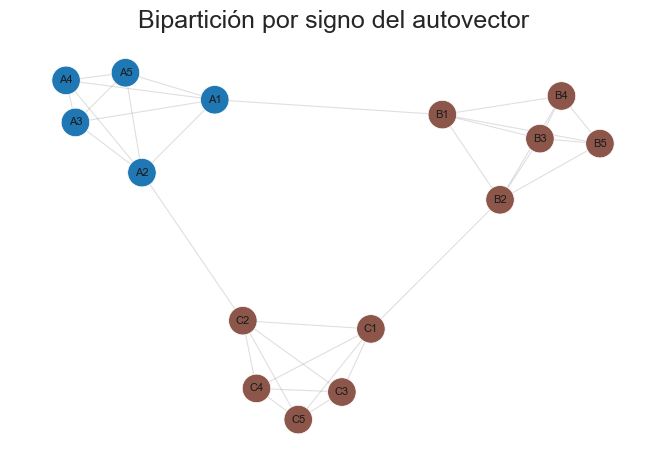

In [ ]:
B_toy, toy_nodes = modularity_matrix(G_toy) # construye la matriz de modularidad para el grafo de juguete
eigvals, eigvecs = np.linalg.eigh(B_toy) # calcula autovalores y autovectores de la matriz de modularidad
top_idx = np.argsort(eigvals)[::-1][:5] # índices de los 5 mayores autovalores (en orden descendente)

spectral_table = pd.DataFrame(
    {"eigenvalue": eigvals[top_idx]},
    index=[f"lambda_{i+1}" for i in range(len(top_idx))]
)

display(spectral_table.style.format({"eigenvalue": "{:.4f}"}))
# ejecuta la bipartición espectral usando la matriz de modularidad y obtiene la partición, el autovalor principal, 
# el autovector principal y el orden de nodos usado para construir la matriz de modularidad
spectral_part_toy, lead_val, lead_vec, nodes_order = run_spectral_bipartition(G_toy)

print("Mayor eigenvalue de B:", round(lead_val, 4))
print("Q de la bipartición espectral:", round(partition_modularity(G_toy, spectral_part_toy), 4))

vec_df = pd.DataFrame({"node": nodes_order, "eigenvector_value": lead_vec})
vec_df["group"] = vec_df["eigenvector_value"].ge(0).astype(int)
display(vec_df.sort_values("eigenvector_value"))
fig, ax = plt.subplots(1, 1, figsize=(7, 5))
plot_partition_on_axis(ax, G_toy, toy_pos, spectral_part_toy, "Bipartición por signo del autovector", labels=True)
plt.tight_layout()
plt.show()


### Interpretación del ejemplo espectral

En este ejemplo aparecen **dos autovalores máximos iguales** ($\lambda_1=\lambda_2=3.8737$). Eso indica que la dirección dominante de la matriz de modularidad no es única: existe un **subespacio principal de dimensión 2** igualmente importante. En términos estructurales, esto es consistente con una red que no tiene una sola separación binaria obvia, sino varias divisiones plausibles de primer nivel.

La red de juguete tiene en realidad **tres bloques visibles** ($A$, $B$, $C$). Sin embargo, el método aplicado aquí es una **bipartición espectral**, no un algoritmo multicomunidad. Por construcción, toma **un autovector principal** y divide los nodos según el **signo** de sus componentes:

- valores negativos $\rightarrow$ grupo 0,
- valores positivos $\rightarrow$ grupo 1.

En la salida obtenida, los nodos del bloque $A$ quedan con valores negativos, mientras que los nodos de $B$ y $C$ quedan con valores positivos. Por eso la bipartición resultante es:

- grupo 0: $A$
- grupo 1: $B \cup C$

Esto **no significa que la red tenga solo dos comunidades**, sino que esta es la **mejor separación binaria** encontrada en este paso del método.

También es importante distinguir entre el **autovalor principal** y la **modularidad $Q$** de la partición obtenida. El valor $3.8737$ es una propiedad espectral de la matriz $B$, mientras que $Q=0.3838$ evalúa la calidad de la partición discreta construida a partir del signo del autovector. No deben coincidir numéricamente: el autovalor guía la partición, pero no es la modularidad misma.

Si quisiéramos recuperar las **tres comunidades** $A$, $B$ y $C$, tendríamos que:

1. aplicar divisiones recursivas sobre los grupos obtenidos, o
2. usar un método que permita detectar directamente más de dos comunidades.

### La noción de red indivisible

Una red puede ser **indivisible** bajo el criterio de modularidad. Esto ocurre cuando no existe una bipartición que aumente el valor de $Q$, es decir:

- no hay una división con ganancia positiva
- separar la red no mejora la modularidad
- por lo tanto, partirla no está justificado bajo ese objetivo

En la formulación espectral, esta idea se conecta con el **mayor autovalor** de la matriz de modularidad $B$. Si el mayor autovalor es **positivo**, entonces existe al menos una dirección en la que la red se aparta del modelo nulo y puede valer la pena intentar una división. Si, en cambio, el mayor autovalor es **no positivo**, la red es **indivisible** en ese paso: no hay evidencia, bajo modularidad, de que una bipartición produzca una mejora real.

Esto es conceptualmente importante por dos razones.

**Primero**, no toda red debe forzarse a exhibir comunidades. A veces la estructura observada no contiene una mesoestructura clara bajo el criterio adoptado, y en ese caso la conclusión correcta no es “el algoritmo falló”, sino que **la red no muestra una partición modular relevante**.

**Segundo**, la indivisibilidad siempre es **relativa al criterio usado**. Una red puede ser indivisible bajo modularidad y, sin embargo, mostrar estructura bajo otro enfoque, como equivalencia estructural, block models o métodos jerárquicos. Por eso, “indivisible” no significa “sin estructura”, sino “sin estructura comunitaria detectable bajo este criterio específico”.

En métodos recursivos de partición, esta idea también actúa como una regla de detención: se divide una red o subred solo mientras la división siga aumentando la modularidad. Cuando eso deja de ocurrir, el bloque se considera terminal.

La figura del karate club ilustra el caso opuesto: allí sí aparece una separación binaria informativa, consistente con una estructura comunitaria clara. Pero el punto metodológico general es que no siempre ocurrirá eso. En algunos casos, la decisión correcta es precisamente **no dividir**.

<div style="text-align:center;">
  <img src="assets/newman2006_fig2_karate.jpg" width="520">
</div>

**Figura:** aplicación clásica del método espectral al karate club.  
**Fuente:** Newman (2006), *Modularity and community structure in networks*.


## 8. Familias principales de algoritmos

Conviene ordenar los métodos por **familia** porque eso permite ver su hipótesis implícita. La pregunta no es solo “qué algoritmo usar”, sino **qué noción de comunidad está codificando** cada algoritmo.

### 8.1 Divisivos: remover puentes para revelar separación

Ejemplo clásico: `Girvan-Newman`.

Lógica:

- si dos grupos están conectados por pocas aristas puente,
- esas aristas deberían concentrar muchos caminos geodésicos entre pares de nodos;
- al remover repetidamente esas aristas, la red se va separando en componentes o subgrupos.

La cantidad central es la **edge betweenness** de una arista $e$:

$$
g_e = \sum_{s \neq t} \frac{\sigma_{st}(e)}{\sigma_{st}},
$$

donde $\sigma_{st}$ es el número de caminos geodésicos entre $s$ y $t$, y $\sigma_{st}(e)$ es cuántos de esos caminos pasan por la arista $e$.

Interpretación:

- si $g_e$ es grande, la arista actúa como cuello de botella;
- al eliminar primero esas aristas, el método intenta “cortar” las conexiones entre grupos.

Ventaja conceptual:

- es excelente para enseñar que una comunidad puede pensarse por **separabilidad** y no solo por densidad interna.

Límite:

- es costoso computacionalmente porque la betweenness debe recalcularse muchas veces.

### 8.2 Espectrales: usar álgebra lineal para encontrar cortes buenos

Ejemplo central en Newman: **spectral modularity**.

Partimos de la modularity matrix $B$, con entradas

$$
B_{ij} = A_{ij} - \frac{k_i k_j}{2m},
$$

donde $A_{ij}$ es la matriz de adyacencia, $k_i$ es el grado del nodo $i$ y $m$ es el número de aristas.

Si codificamos una bipartición con un vector $s \in \{-1,+1\}^n$, entonces la modularidad de esa bipartición puede escribirse como

$$
Q = \frac{1}{4m} s^\top B s.
$$

La idea espectral es:

- relajar el problema combinatorio exacto;
- mirar el autovector asociado al mayor autovalor de $B$;
- asignar nodos según el signo de sus entradas.

Intuición matemática:

- si el mayor autovalor positivo es grande, existe una dirección en el espacio de particiones que incrementa $Q$;
- el autovector principal aproxima esa dirección de máxima ganancia.

Ventaja:

- conecta de forma muy limpia la definición de modularidad con un método de partición.

Límite:

- naturalmente produce una **bipartición** en cada paso; para más de dos grupos se necesita partición recursiva o variantes más sofisticadas.

### 8.3 Optimización de modularidad: buscar particiones con $Q$ alto

Aquí están muchos de los métodos más usados en práctica.

Recordatorio:

$$
Q = \frac{1}{2m} \sum_{ij} \left(A_{ij} - \frac{k_i k_j}{2m}\right) \delta(c_i,c_j),
$$

donde $\delta(c_i,c_j)=1$ si $i$ y $j$ quedan en la misma comunidad.

La lógica general es siempre la misma:

- comparar enlaces observados dentro de una comunidad contra los que esperaríamos bajo el nulo de grados;
- preferir movimientos o fusiones que aumenten esa diferencia agregada.

#### **Greedy modularity**:

- comienza con todos los nodos separados
- en cada paso fusiona el par de comunidades que genera el mayor incremento de $Q$
- es un procedimiento aglomerativo

#### **Louvain**:

- fase 1: mueve un nodo $i$ a la comunidad vecina que más aumenta $Q$
- fase 2: contrae cada comunidad en un supernodo
- repite ambas fases hasta que no hay mejora adicional

La ganancia local puede leerse, de manera simplificada, como:

$$
\Delta Q(i \to C) \propto k_{i,in}(C) - \gamma \frac{k_i\,\Sigma_{tot}(C)}{2m},
$$

donde $k_{i,in}(C)$ es el peso de los enlaces de $i$ hacia la comunidad $C$, y $\Sigma_{tot}(C)$ es la suma de grados de esa comunidad. El movimiento favorecido es, por tanto, aquel donde la conexión observada con $C$ excede suficientemente la esperada bajo el nulo.


#### **Leiden**:

* mantiene la lógica multinivel de Louvain: mover nodos localmente y luego construir una red agregada
* pero antes de agregar, introduce una fase extra de **refinamiento**
* esa fase toma las comunidades provisionales encontradas y **verifica si realmente están bien conectadas internamente**
* si una comunidad quedó armada de forma pobre, con partes débilmente conectadas o incluso desconectadas, Leiden **la subdivide o reordena internamente** antes de colapsarla
* solo después de ese refinamiento construye la red agregada del siguiente nivel
* así, la agregación no se hace sobre comunidades “crudas”, sino sobre comunidades ya depuradas

**Intuición**:

* Louvain puede decir: “esta comunidad mejora modularidad, así que la acepto”
* Leiden agrega una pregunta extra: “¿además de mejorar modularidad, esta comunidad está bien conectada por dentro?”;
* si la respuesta es no, la refina antes de seguir.

**Qué gana con eso**:

* evita comunidades internamente desconectadas;
* reduce comunidades artificiales pegadas solo porque mejoraban modularidad localmente;
* produce particiones más robustas y mejor conectadas.

Punto clave:

* `Greedy`, `Louvain` y `Leiden` pertenecen a la misma familia amplia porque buscan particiones con **alta modularidad**;
* la diferencia está en **cómo exploran el espacio de particiones**
* `Louvain` mejora modularidad y luego agrega
* `Leiden` mejora modularidad, **refina la conectividad interna de las comunidades**, y recién después agrega
* por eso Leiden suele considerarse una mejora sobre Louvain, no porque cambie el objetivo central, sino porque hace más cuidadoso el camino para alcanzarlo



### 8.4 Propagación local: consenso emergente sin función global explícita

Ejemplo: `label propagation`.

Lógica:

- cada nodo parte con una etiqueta;
- en cada iteración adopta la etiqueta más frecuente entre sus vecinos.

Una forma esquemática de escribirlo es:

$$
c_i^{(t+1)} = \operatorname{mode}\{c_j^{(t)} : j \in N(i)\}.
$$

Aquí, $c_i^{(t+1)}$ representa la etiqueta que tendrá el nodo $i$ en la iteración siguiente, mientras que $c_j^{(t)}$ representa la etiqueta que tiene un vecino $j$ de $i$ en la iteración actual. El conjunto $N(i)$ denota todos los vecinos de $i$, y $\operatorname{mode}$ indica la **moda**, es decir, la etiqueta más frecuente entre ellos.

La regla completa se interpreta así: en cada ronda, el nodo $i$ observa las etiquetas de sus vecinos y adopta la que aparece con mayor frecuencia. Por tanto, la actualización es puramente **local**: cada nodo decide en función de su entorno inmediato, sin optimizar explícitamente una función global como la modularidad.

La intuición es que, si un subconjunto de nodos está densamente conectado, sus etiquetas tenderán a reforzarse mutuamente hasta volverse dominantes dentro de esa región. De esta manera, las comunidades emergen como estados relativamente estables de consenso local.

En caso de empate entre varias etiquetas, el algoritmo necesita una regla adicional de desempate, por ejemplo elegir una al azar o mantener la etiqueta previa. Ese detalle puede afectar el resultado final, lo que explica por qué `label propagation` puede ser rápido pero también algo inestable entre corridas.


Ventaja:

- muy rápido y útil como baseline.

Límite:

- no optimiza una función global como $Q$;
- puede ser inestable entre corridas y sensible al orden de actualización.



## 8.5 Basados en flujos: comprimir recorridos aleatorios

Ejemplo representativo: `Infomap`.

Acá la idea de comunidad cambia un poco. Ya no pensamos primero en un grupo con muchos enlaces internos, como en modularidad. En cambio, pensamos en **cómo circula algo por la red**.

Imaginemos una **caminata aleatoria**: un nodo pasa a uno de sus vecinos, luego a otro, y así sucesivamente. Si la red tiene módulos bien definidos, esa caminata va a tender a:

* entrar a una zona,
* moverse bastante dentro de esa zona,
* y salir de ella con menos frecuencia.

Entonces, una comunidad se entiende como una región de la red que **retiene flujo**.

### La intuición de Infomap

Infomap toma esa idea y la transforma en un problema de **compresión**.

La pregunta es:

> si yo quisiera describir el recorrido de esa caminata aleatoria, ¿qué partición de la red me permitiría describirlo de la forma más eficiente posible?

La lógica es esta:

* si la caminata pasa mucho tiempo dentro de un mismo módulo,
* entonces conviene usar un código corto para los movimientos internos;
* y un código aparte para registrar cuándo salta de un módulo a otro.

Si la partición está bien elegida, el recorrido completo se puede describir con menos información.

### La ecuación

Eso se resume en la **map equation**:

$$
L(M) = q_{\curvearrowright} H(Q) + \sum_{r=1}^{m} p^{r}_{\circlearrowright} H(P^r),
$$

No hace falta memorizarla. Lo importante es entender qué representa:

* $L(M)$ es el **costo total de describir el recorrido** bajo una partición $M$;
* el primer término mide el costo de decir **cuándo la caminata cambia de módulo**;
* el segundo término mide el costo de decir **cómo se mueve dentro de cada módulo**.

La mejor partición es la que **minimiza** ese costo total.

### Qué significa eso intuitivamente

Si una partición es buena para Infomap, entonces:

* los cambios entre módulos son poco frecuentes;
* gran parte del recorrido ocurre dentro de módulos;
* y por eso la trayectoria se puede codificar de manera más compacta.

Entonces, para Infomap, una comunidad no es solo un grupo denso. Es una región donde un recorrido aleatorio **tiende a quedarse**.

### Cuándo este enfoque es especialmente útil

Este enfoque tiene mucho sentido cuando la red representa algo como:

* navegación,
* movilidad,
* difusión,
* transporte,
* circulación de información.

Ahí la pregunta sustantiva no es solo “quién está conectado con quién”, sino también **por dónde se mueve el flujo y dónde permanece**.

### Diferencia con modularidad

Esto es clave:

* **modularidad** busca grupos con más enlaces internos de los esperados;
* **Infomap** busca grupos que permiten describir mejor un flujo sobre la red.

Por eso no tiene sentido juzgar Infomap solo por modularidad $Q$.
No está optimizando la misma cosa.

### Entonces

> En modularidad, una comunidad es un grupo sorprendentemente cohesionado.
> En Infomap, una comunidad es una región donde el flujo tiende a permanecer y que por eso permite comprimir mejor la trayectoria.


### 8.6 Basados en modelos: inferir bloques como mecanismo generativo

Ejemplo: `SBM inference`.

Aquí la lógica cambia otra vez. En vez de preguntar *“qué partición hace grande a $Q$?”* o *“qué partición comprime mejor un flujo?”*, la pregunta pasa a ser:

> **¿qué modelo probabilístico podría haber generado esta red?**

La idea del `stochastic block model` (SBM) es asumir que cada nodo pertenece a un bloque latente, denotado por $z_i$, y que la probabilidad de que dos nodos se conecten depende solo de los bloques a los que pertenecen.

Una versión simple del modelo se escribe así:

$$
\Pr(A \mid z, P) = \prod_{i<j} P_{z_i z_j}^{A_{ij}} (1-P_{z_i z_j})^{1-A_{ij}}.
$$

No es necesario quedarse pegado en la fórmula. Lo importante es la lógica:

- $A$ es la red observada;
- $z_i$ indica a qué bloque pertenece el nodo $i$;
- $P_{rs}$ es la probabilidad de enlace entre un nodo del bloque $r$ y uno del bloque $s$.

Entonces, si $z_i = r$ y $z_j = s$, el enlace entre $i$ y $j$ se modela con probabilidad $P_{rs}$.

Concretamente, la expresión $\Pr(A \mid z, P)$ representa la probabilidad de observar la red $A$ dado un vector de bloques $z$ y una matriz de probabilidades entre bloques $P$. La parte derecha construye esa probabilidad multiplicando la contribución de cada par de nodos.

Para cada par $(i,j)$, si se observa un enlace ($A_{ij}=1$), la contribución es $P_{z_i z_j}$; si no se observa enlace ($A_{ij}=0$), la contribución es $1-P_{z_i z_j}$. Los exponentes $A_{ij}$ y $1-A_{ij}$ permiten escribir ambos casos en una sola expresión compacta.

En esta versión simple del SBM, la red se modela como el resultado de muchas decisiones de enlace/no enlace entre pares de nodos, donde la probabilidad de conexión depende solo de los bloques a los que pertenecen los nodos.


### Intuición

La gracia del enfoque es que ya no define comunidad solo por densidad interna. En cambio, intenta encontrar una asignación de bloques que haga **probable** la red observada bajo un mecanismo generativo explícito.

En otras palabras, no pregunta solamente:

> “¿qué nodos están densamente conectados entre sí?”

sino más bien:

> “¿qué partición explica mejor el patrón completo de enlaces de la red?”

Eso permite detectar no solo comunidades assortativas clásicas, sino también otras formas de organización.

### Qué tipo de estructuras puede capturar

Dependiendo de los valores de la matriz $P$, el modelo puede representar:

- **estructura assortativa**: más enlaces dentro de bloques que entre ellos;
- **estructura disassortativa**: más enlaces entre bloques que dentro de ellos;
- **core-periphery**: un bloque central muy conectado y otros periféricos;
- **estructuras mixtas o más complejas**, según la variante del modelo.

Ese es un punto fuerte de los SBM: no obligan a que toda estructura relevante sea “comunidad densa” en el sentido clásico.

### Qué se infiere en la práctica

El objetivo es inferir:

- la asignación de bloques $z$;
- y los parámetros del modelo, es decir, las probabilidades $P_{rs}$ entre bloques.

Dicho simple: queremos descubrir tanto **quién pertenece a qué bloque** como **cómo interactúan esos bloques entre sí**.

### Ventajas

- ofrece un marco estadístico explícito;
- hace visibles los supuestos del modelo;
- permite comparar explicaciones alternativas de la red;
- puede capturar estructuras más generales que la modularidad.

### Límites

- exige más modelamiento y más supuestos;
- requiere más cuidado computacional;
- y los resultados dependen de la variante elegida y de cómo se ajusta el modelo.

### Idea clave

> En modularidad, buscamos una partición con cohesión interna "sorprendente" (más allá del azar).  
> En un SBM, buscamos una partición que explique probabilísticamente cómo se generó la red.

Por eso, los métodos basados en modelos no preguntan exactamente lo mismo que Louvain, Leiden o Infomap. No están optimizando una partición "buena" según un criterio geométrico o informacional, sino ajustando una hipótesis estadística sobre el mecanismo generativo de la red.



### 8.7 Qué debe retenerse de esta taxonomía

- Los métodos **divisivos** privilegian puentes y separación.
- Los métodos **espectrales** traducen el problema a álgebra lineal.
- Los métodos de **optimización de modularidad** buscan particiones con exceso de densidad intra-grupo respecto de un nulo.
- Los métodos de **propagación local** privilegian consenso vecinal y velocidad.
- Los métodos **basados en flujos** detectan persistencia de recorridos.
- Los métodos **basados en modelos** preguntan qué partición explica mejor la red como realización de un mecanismo probabilístico.

La consecuencia metodológica es directa: **algoritmos distintos no son intercambiables**, porque formalizan definiciones distintas de comunidad.


In [25]:
algo_df = pd.DataFrame([
    {"algorithm": "Girvan-Newman", "family": "divisive", "principle": "elimina aristas con alta edge betweenness", "objective": "secuencia de cortes; no optimiza Q directamente", "strength": "muy interpretable", "weakness": "muy costoso"},
    {"algorithm": "Spectral modularity", "family": "spectral", "principle": "usa el autovector principal de B", "objective": "aproxima particiones con alto Q", "strength": "muy buena intuición matemática", "weakness": "naturalmente bipartitivo"},
    {"algorithm": "Greedy modularity", "family": "modularity optimization", "principle": "fusiona maximizando incrementos de Q", "objective": "modularity", "strength": "rápido y reproducible", "weakness": "puede congelar decisiones"},
    {"algorithm": "Louvain", "family": "multilevel modularity", "principle": "local moving + agregación", "objective": "modularity", "strength": "muy rápido y estándar", "weakness": "sensible a seed; conectividad interna imperfecta"},
    {"algorithm": "Leiden", "family": "multilevel modularity", "principle": "Louvain + refinamiento", "objective": "modularity o CPM", "strength": "mejor conectividad interna", "weakness": "requiere paquete adicional"},
    {"algorithm": "Label propagation", "family": "local propagation", "principle": "difusión iterativa de etiquetas", "objective": "sin función global explícita", "strength": "muy rápido", "weakness": "más inestable"},
    {"algorithm": "Infomap", "family": "flow-based", "principle": "comprime recorridos aleatorios", "objective": "minimiza la map equation", "strength": "capta persistencia de flujos", "weakness": "no es comparable a Q en forma directa"},
    {"algorithm": "SBM inference", "family": "model-based", "principle": "ajusta un modelo generativo de bloques", "objective": "likelihood/posterior", "strength": "marco probabilístico potente", "weakness": "más complejo de ajustar"},
])
display(algo_df)


,algorithm,family,principle,objective,strength,weakness
0,Girvan-Newman,divisive,elimina aristas con alta edge betweenness,secuencia de cortes; no optimiza Q directamente,muy interpretable,muy costoso
1,Spectral modularity,spectral,usa el autovector principal de B,aproxima particiones con alto Q,muy buena intuición matemática,naturalmente bipartitivo
2,Greedy modularity,modularity optimization,fusiona maximizando incrementos de Q,modularity,rápido y reproducible,puede congelar decisiones
3,Louvain,multilevel modularity,local moving + agregación,modularity,muy rápido y estándar,sensible a seed; conectividad interna imperfecta
4,Leiden,multilevel modularity,Louvain + refinamiento,modularity o CPM,mejor conectividad interna,requiere paquete adicional
5,Label propagation,local propagation,difusión iterativa de etiquetas,sin función global explícita,muy rápido,más inestable
6,Infomap,flow-based,comprime recorridos aleatorios,minimiza la map equation,capta persistencia de flujos,no es comparable a Q en forma directa
7,SBM inference,model-based,ajusta un modelo generativo de bloques,likelihood/posterior,marco probabilístico potente,más complejo de ajustar


## 9. Comparación viz a viz: similitudes y diferencias

### Girvan-Newman vs modularidad
`Girvan-Newman` no optimiza modularidad directamente; produce una secuencia de cortes que luego puede evaluarse.

### Greedy vs Louvain
Ambos persiguen modularidad, pero `Louvain` usa una lógica multinivel que suele explorar mejor el espacio.

### Louvain vs Leiden
Ambos son multinivel; `Leiden` refina antes de agregar y por eso suele comportarse mejor.

### Spectral vs Louvain
`Spectral modularity` es más cercano a la formulación algebraica de Newman; `Louvain` es más cercano a la práctica de gran escala. Ojo, Louvain no es una generalización del método espectral, sino una heurística distinta para optimizar modularidad. Ambos comparten el mismo objetivo, pero difieren en la forma de explorar el espacio de particiones: el método espectral usa autovectores de la matriz de modularidad, mientras Louvain usa movimientos locales y agregación multinivel.

### Label propagation vs todos los anteriores
Su ventaja es velocidad; su desventaja es menor trazabilidad.


## 10. Qué significa una comparación seria de algoritmos

Una comparación profesional no se reduce a una tabla con `Q`.

Debe considerar:

- lógica del método
- tipo de estructura favorecida
- escala observada
- estabilidad
- costo computacional
- y, cuando existe, coherencia con evidencia externa


## 11. Comparación empírica 1: Karate Club

`Karate Club` es útil porque:

- es pequeña y visualizable;
- tiene una referencia externa;
- permite ver diferencias entre algoritmos sin esconder la red detrás de una escala grande.


In [ ]:
G_karate = nx.karate_club_graph()
karate_external = {n: 0 if G_karate.nodes[n]["club"] == "Mr. Hi" else 1 for n in G_karate.nodes()}
karate_pos = nx.spring_layout(G_karate, seed=7)

# ejecuta la suite de métodos de detección de comunidades en el grafo de la red de karate, 
# usando las etiquetas de club como verdad externa para evaluación
karate_results, karate_parts = run_method_suite(G_karate, external_labels=karate_external, weight=None, seed=42)
display(karate_results.sort_values(["modularity", "ARI"], ascending=[False, False]).style.format(
    {"modularity": "{:.4f}", "ARI": "{:.4f}", "NMI": "{:.4f}", "runtime_sec": "{:.4f}", "lead_eigenvalue": "{:.4f}"}
))


,method,n_communities,largest_community,modularity,runtime_sec,ARI,NMI,lead_eigenvalue,gn_best_level_k
4,louvain,4,14,0.4151,0.0048,0.5089,0.6000,nan,nan
3,label_propagation,4,14,0.4033,0.0022,0.4588,0.5056,nan,nan
1,girvan_newman,5,12,0.4013,0.0640,0.3916,0.4851,nan,5.000000
2,greedy_modularity,3,17,0.3807,0.0053,0.5684,0.5646,nan,nan
0,spectral_bipartition,2,18,0.3715,0.0181,0.8823,0.8372,4.9771,nan


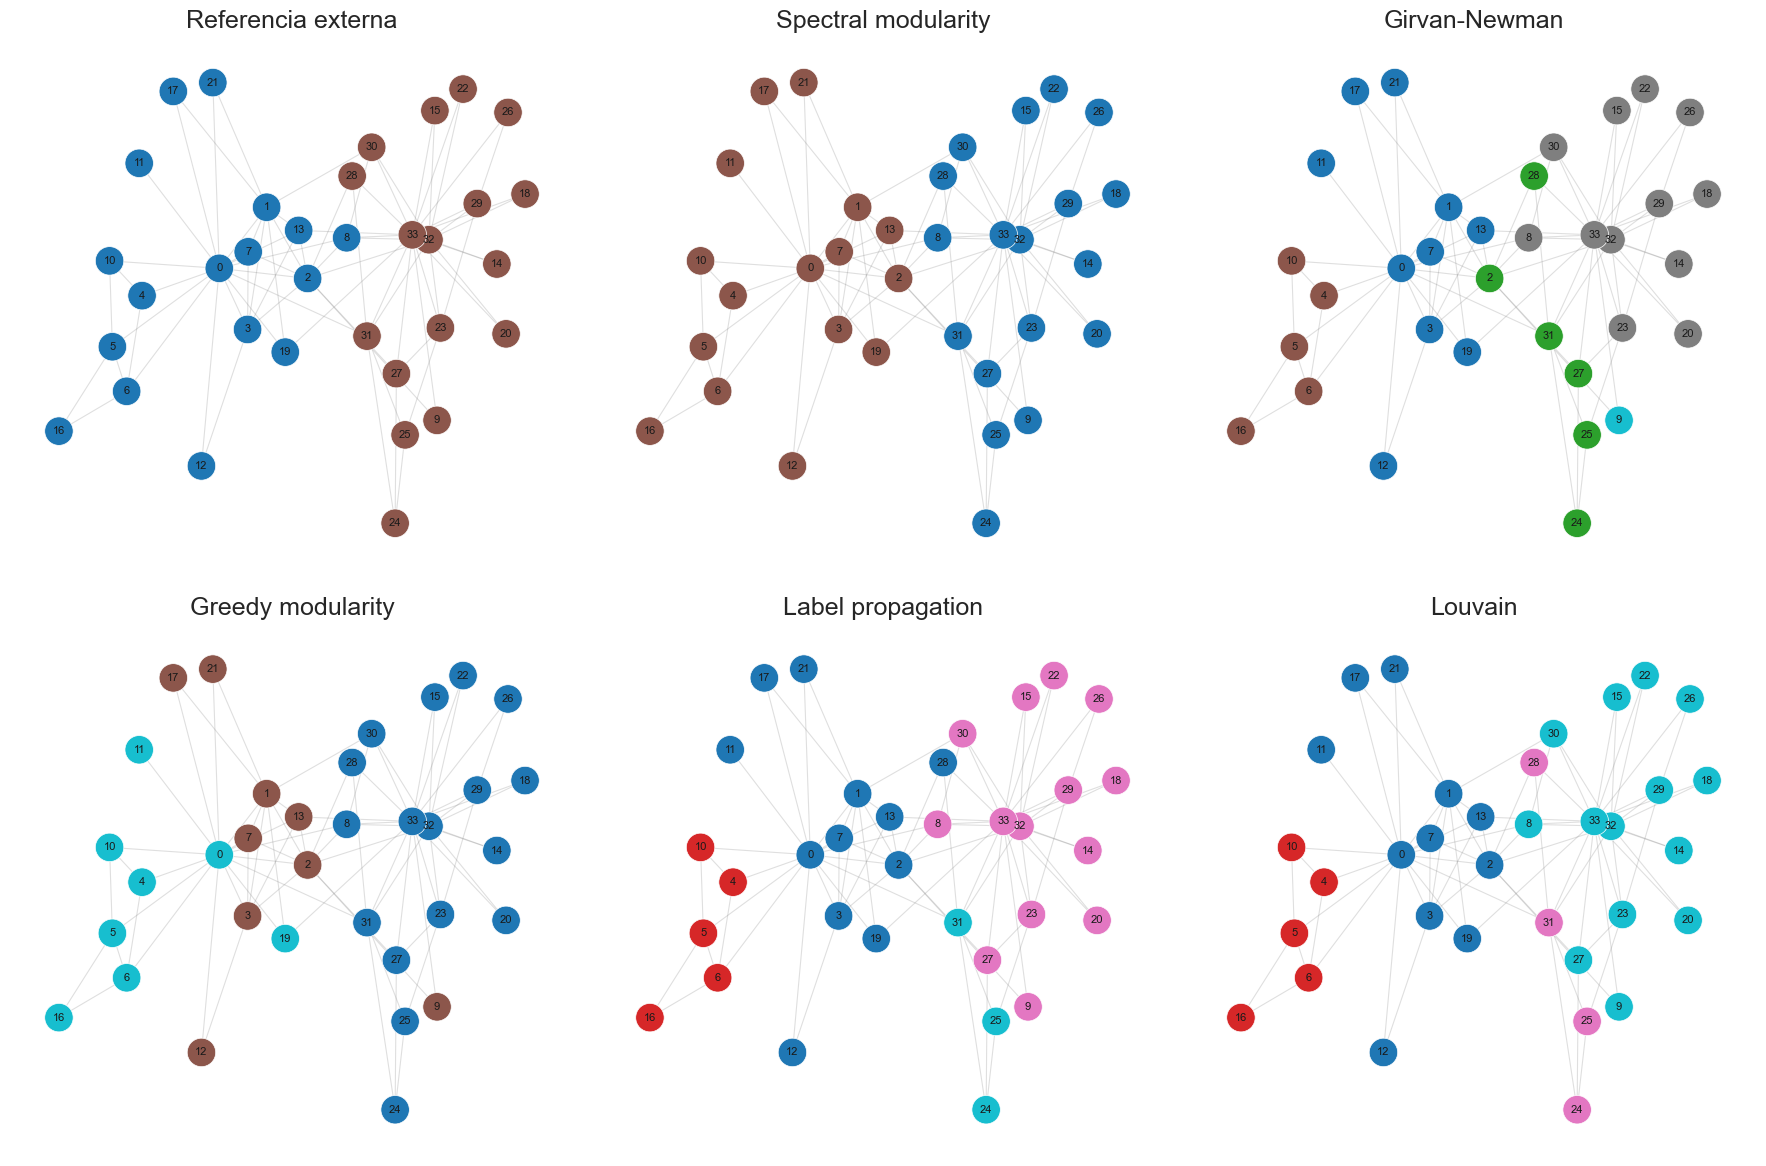

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()
plot_partition_on_axis(axes[0], G_karate, karate_pos, karate_external, "Referencia externa", labels=True)
plot_partition_on_axis(axes[1], G_karate, karate_pos, karate_parts["spectral_bipartition"], "Spectral modularity", labels=True)
plot_partition_on_axis(axes[2], G_karate, karate_pos, karate_parts["girvan_newman"], "Girvan-Newman", labels=True)
plot_partition_on_axis(axes[3], G_karate, karate_pos, karate_parts["greedy_modularity"], "Greedy modularity", labels=True)
plot_partition_on_axis(axes[4], G_karate, karate_pos, karate_parts["label_propagation"], "Label propagation", labels=True)
plot_partition_on_axis(axes[5], G_karate, karate_pos, karate_parts["louvain"], "Louvain", labels=True)
plt.tight_layout()
plt.show()


### Lectura de Karate

El panel deja ver que distintos algoritmos pueden producir particiones plausibles pero no idénticas porque están priorizando principios distintos. La comparación no debe leerse como qué algoritmo "gana" vs "pierde", sino como contraste entre lógicas de detección.


## 12. Comparación empírica 2: SBM con ground truth


El `SBM` sirve para evaluar algoritmos cuando la estructura assortativa fue incorporada explícitamente en la generación de la red.


In [15]:
sizes = [45, 35, 30]
P = [
    [0.18, 0.03, 0.02],
    [0.03, 0.16, 0.04],
    [0.02, 0.04, 0.14],
]
G_sbm = nx.stochastic_block_model(sizes, P, seed=42)
sbm_truth = {}
start = 0
for block_idx, size in enumerate(sizes):
    for node in range(start, start + size):
        sbm_truth[node] = block_idx
    start += size
sbm_pos = nx.spring_layout(G_sbm, seed=42, k=0.16, iterations=200)
sbm_results, sbm_parts = run_method_suite(G_sbm, external_labels=sbm_truth, weight=None, seed=42)
display(sbm_results.sort_values(["ARI", "modularity"], ascending=[False, False]).style.format(
    {"modularity": "{:.4f}", "ARI": "{:.4f}", "NMI": "{:.4f}", "runtime_sec": "{:.4f}", "lead_eigenvalue": "{:.4f}"}
))


,method,n_communities,largest_community,modularity,runtime_sec,ARI,NMI,lead_eigenvalue,gn_best_level_k
1,girvan_newman,9,44,0.3777,3.2951,0.7457,0.7253,nan,9.000000
0,spectral_bipartition,2,66,0.3576,0.0030,0.6172,0.7163,6.7692,nan
2,greedy_modularity,4,40,0.3825,0.0366,0.5991,0.5616,nan,nan
3,label_propagation,8,46,0.3654,0.0045,0.5364,0.4781,nan,nan
4,louvain,5,41,0.3921,0.0112,0.5318,0.5202,nan,nan


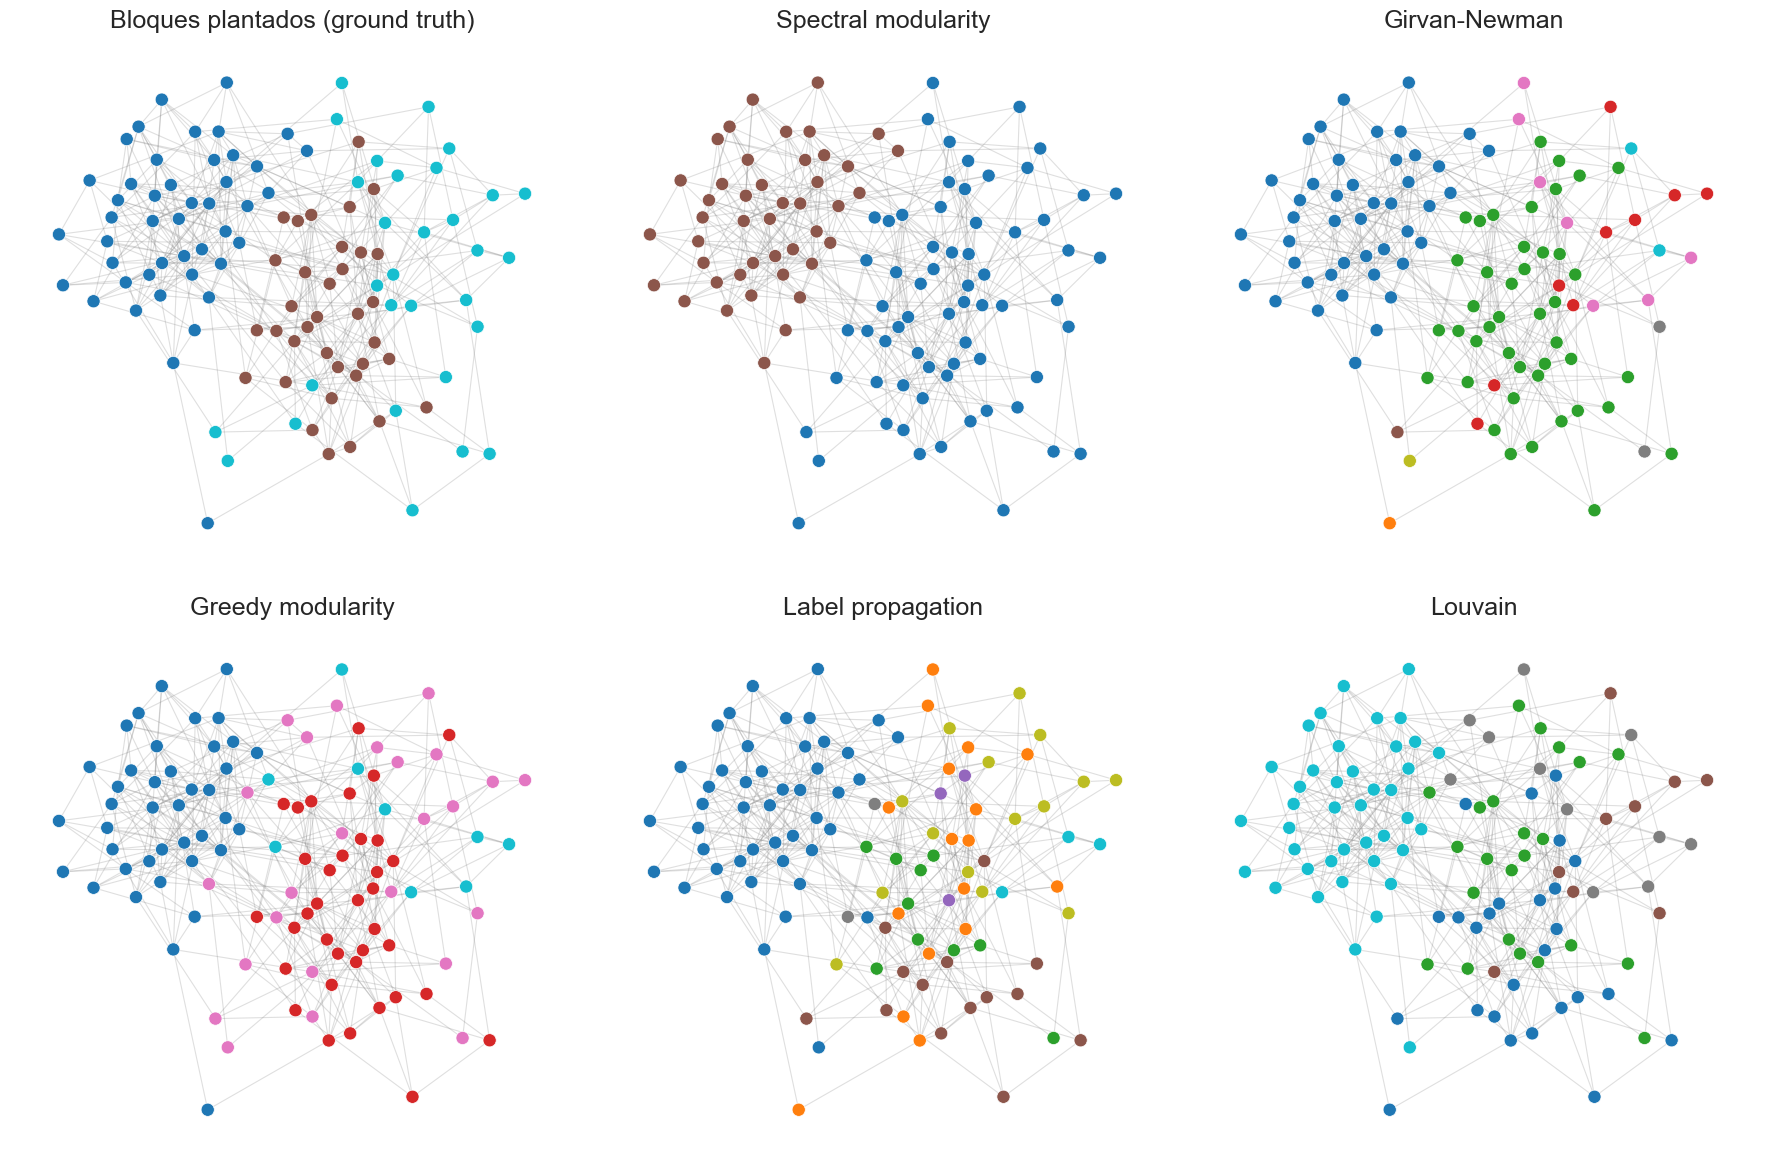

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()
plot_partition_on_axis(axes[0], G_sbm, sbm_pos, sbm_truth, "Bloques plantados (ground truth)", labels=False)
plot_partition_on_axis(axes[1], G_sbm, sbm_pos, sbm_parts["spectral_bipartition"], "Spectral modularity", labels=False)
plot_partition_on_axis(axes[2], G_sbm, sbm_pos, sbm_parts["girvan_newman"], "Girvan-Newman", labels=False)
plot_partition_on_axis(axes[3], G_sbm, sbm_pos, sbm_parts["greedy_modularity"], "Greedy modularity", labels=False)
plot_partition_on_axis(axes[4], G_sbm, sbm_pos, sbm_parts["label_propagation"], "Label propagation", labels=False)
plot_partition_on_axis(axes[5], G_sbm, sbm_pos, sbm_parts["louvain"], "Louvain", labels=False)
plt.tight_layout()
plt.show()


### Qué enseña el SBM

Cuando la red se parece a la intuición assortativa que privilegian los métodos de modularidad, esos métodos suelen comportarse bien. Eso no significa que modularidad sea la única noción válida de comunidad; significa que método y estructura subyacente son compatibles.


## 13. Estabilidad y consenso

Un análisis serio no debería quedarse con una sola corrida. Esto es especialmente importante para métodos heurísticos como `Louvain` y también para `Leiden`, aunque este último suele comportarse mejor en conectividad interna.

Protocolo mínimo para práctica aplicada:

- correr el algoritmo con múltiples `seeds`
- registrar `Q`, número de comunidades y acuerdos entre particiones
- inspeccionar una matriz de coasignación o una partición de consenso
- revisar si las conclusiones sustantivas sobreviven al cambio de `seed`

Regla importante:

- conviene comparar `Leiden` con `Louvain` bajo el mismo `resolution`
- si la partición cambia mucho entre corridas, eso no se "corrige" eligiendo la que más guste: se **reporta** como inestabilidad inferencial.

Aquí, a modo de ejemplo, ilustramos el protocolo con `Louvain` y `label propagation`. En la práctica, la misma lógica debe aplicarse a `Louvain/Leiden` u otros.


,method,mean_modularity,std_modularity,mean_n_communities,mean_ARI,mean_NMI
0,louvain,0.3888,0.0080,5.00,0.5353,0.5795
1,label_propagation,0.2515,0.1596,3.20,0.3102,0.3557


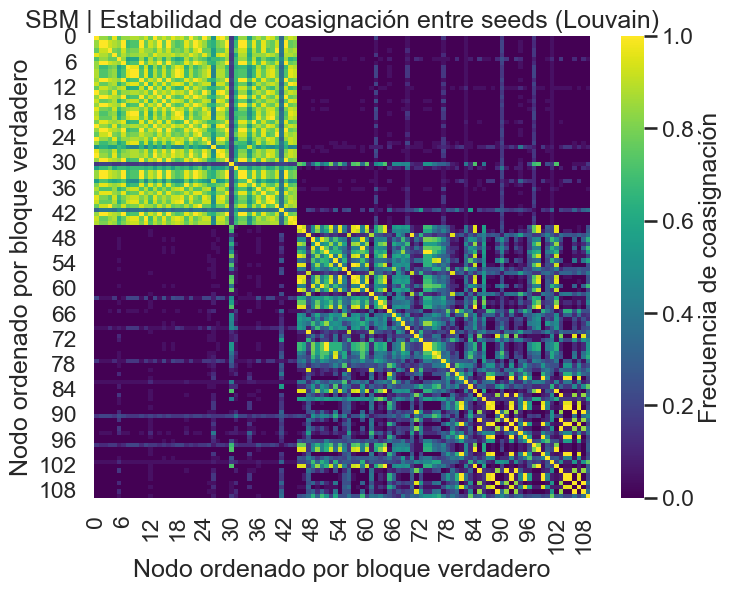

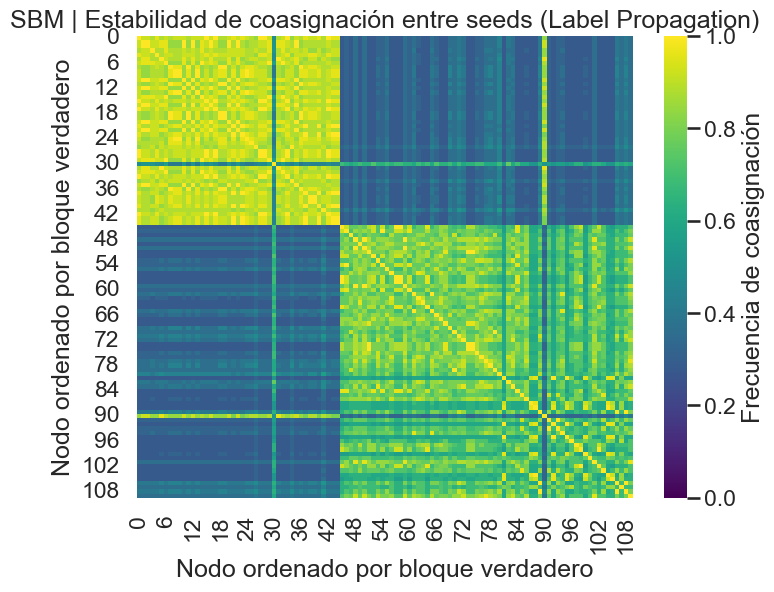

In [ ]:
seeds = list(range(25))

# ejecuta múltiples veces los algoritmos de Louvain y Label Propagation con diferentes 
# seeds para evaluar la estabilidad de las particiones obtenidas
lou_partitions = [run_louvain(G_sbm, seed=s, resolution=1.0, weight=None) for s in seeds]
lpa_partitions = [run_label_propagation(G_sbm, seed=s, weight=None) for s in seeds]


stability_df = pd.DataFrame([
    {
        "method": "louvain",
        "mean_modularity": np.mean([partition_modularity(G_sbm, p) for p in lou_partitions]),
        "std_modularity": np.std([partition_modularity(G_sbm, p) for p in lou_partitions]),
        "mean_n_communities": np.mean([len(set(p.values())) for p in lou_partitions]),
        **pairwise_agreement(lou_partitions),
    },
    {
        "method": "label_propagation",
        "mean_modularity": np.mean([partition_modularity(G_sbm, p) for p in lpa_partitions]),
        "std_modularity": np.std([partition_modularity(G_sbm, p) for p in lpa_partitions]),
        "mean_n_communities": np.mean([len(set(p.values())) for p in lpa_partitions]),
        **pairwise_agreement(lpa_partitions),
    },
])
display(stability_df.style.format(
    {"mean_modularity": "{:.4f}", "std_modularity": "{:.4f}", "mean_n_communities": "{:.2f}", "mean_ARI": "{:.4f}", "mean_NMI": "{:.4f}"}
))

ordered_nodes = sorted(G_sbm.nodes(), key=lambda n: sbm_truth[n])
M = coassignment_matrix(lou_partitions, ordered_nodes)
plt.figure(figsize=(8, 6))
if sns is not None:
    sns.heatmap(M, cmap="viridis", vmin=0, vmax=1, cbar_kws={"label": "Frecuencia de coasignación"})
else:
    plt.imshow(M, cmap="viridis", vmin=0, vmax=1)
    plt.colorbar(label="Frecuencia de coasignación")
plt.title("SBM | Estabilidad de coasignación entre seeds (Louvain)")
plt.xlabel("Nodo ordenado por bloque verdadero")
plt.ylabel("Nodo ordenado por bloque verdadero")
plt.show()


M = coassignment_matrix(lpa_partitions, ordered_nodes)
plt.figure(figsize=(8, 6))
if sns is not None:
    sns.heatmap(M, cmap="viridis", vmin=0, vmax=1, cbar_kws={"label": "Frecuencia de coasignación"})
else:
    plt.imshow(M, cmap="viridis", vmin=0, vmax=1)
    plt.colorbar(label="Frecuencia de coasignación")
plt.title("SBM | Estabilidad de coasignación entre seeds (Label Propagation)")
plt.xlabel("Nodo ordenado por bloque verdadero")
plt.ylabel("Nodo ordenado por bloque verdadero")
plt.show()

### Estabilidad entre corridas en el SBM

Aquí repetimos los algoritmos varias veces sobre la **misma red SBM**, cambiando solo la `seed`. La idea es simple:

> **ver si el algoritmo encuentra prácticamente lo mismo cada vez, o si cambia mucho entre corridas.**

En este ejemplo, la red fue generada con **3 bloques verdaderos**. Por eso, al mirar los resultados conviene tener en mente dos preguntas:

1. **¿qué tan estable es el método?**
2. **¿la escala de la partición se parece a los 3 bloques plantados?**

---

### Qué muestra la tabla

La tabla resume, para cada método:

- **`mean_modularity`**: modularidad promedio de las particiones encontradas;
- **`std_modularity`**: cuánto cambia esa modularidad entre corridas;
- **`mean_n_communities`**: número promedio de comunidades detectadas;
- **`mean_ARI`** y **`mean_NMI`**: cuánto se parecen entre sí las particiones obtenidas en distintas corridas.

La lectura general es:

- **Louvain** obtiene una modularidad promedio mayor y cambia muy poco entre corridas
- además, sus particiones se parecen bastante entre sí
- **Label Propagation** tiene menor modularidad promedio, más variación entre corridas y menor acuerdo entre particiones

Hasta ahí, Louvain se ve más estable.

Pero hay un detalle importante: la red verdadera tiene **3 bloques**, y:

- **Louvain** detecta en promedio **5 comunidades**;
- **Label Propagation** detecta en promedio **3.2 comunidades**.

Eso sugiere que Louvain, aunque es más estable, **tiende a partir la red en más grupos de los que realmente fueron plantados**. En cambio, Label Propagation queda más cerca de la escala verdadera, aunque de manera menos consistente.

---

### Qué muestra la matriz de coasignación

La matriz de coasignación muestra, para cada par de nodos, **con qué frecuencia quedaron en la misma comunidad** a lo largo de las corridas.

Cada entrada $M_{ij}$ se interpreta así:

- $M_{ij}=1$: esos dos nodos siempre quedaron juntos
- $M_{ij}=0$: nunca quedaron juntos
- valores intermedios: a veces sí, a veces no

Los nodos están ordenados por su **bloque verdadero**. Como la red tiene **3 bloques**, lo ideal sería ver:

- **tres bloques claros sobre la diagonal**;
- y valores bajos fuera de esos bloques.

---

### Cómo leer Louvain

En Louvain se observan zonas bien definidas y bastante consistentes. Eso muestra que el método es **estable**.

Pero la figura no reproduce simplemente **3 bloques grandes**. Más bien aparecen subdivisiones internas. Eso coincide con la tabla: Louvain encuentra en promedio **5 comunidades**, no 3.

Entonces, para esta red, Louvain parece:

- capturar bien que hay estructura comunitaria
- hacerlo de manera bastante reproducible
- pero **dividir algunos bloques verdaderos en grupos más pequeños**

---

### Cómo leer Label Propagation

En `Label Propagation` la estructura general se parece más a **3 grupos grandes**, lo que está más cerca de la verdad plantada del SBM.

Sin embargo, dentro de esos bloques hay más mezcla de colores y más variación. Eso indica que la partición cambia más entre corridas: el método capta la escala general, pero con menos precisión y menos estabilidad.

Entonces, para esta red, `Label Propagation` parece:

- recuperar mejor la idea de **3 bloques grandes**
- pero hacerlo de manera más sensible a la semilla
- y con fronteras menos nítidas entre comunidades

---

### Idea principal

Este ejemplo deja una lección importante:

> **una partición puede verse bien en modularidad y estabilidad, pero no necesariamente coincidir con la escala verdadera de la red.**

En este caso:

- **Louvain** es más estable y obtiene mejor modularidad, pero tiende a fragmentar de más;
- **Label Propagation** es menos estable, pero queda más cerca de los **3 bloques plantados**.

Por eso, al evaluar algoritmos de comunidades, no conviene mirar solo una métrica. También hay que mirar:

- **qué tan estable es la solución**,
- **cuántas comunidades está encontrando**,
- y **si esa escala tiene sentido para el problema que estamos estudiando**.

## 14. Resolución, degeneracy y escala observada

Modularidad no tiene una escala universal correcta. Para mostrarlo con claridad, usamos `ring_of_cliques`.


### ¿Qué es *resolution*?

En métodos como Louvain, `resolution` controla la **escala** a la que buscamos comunidades.

- una resolución más baja tiende a favorecer comunidades más grandes, fusionando módulos;
- una resolución más alta tiende a favorecer comunidades más pequeñas, separando módulos.

Por eso, cambiar `resolution` puede cambiar bastante el número de comunidades detectadas, incluso en la misma red.

La idea importante para clase es esta:

> **la comunidad detectada no depende solo de la red, sino también de la escala a la que decidimos mirar esa red.**

En el `ring of cliques`, la estructura plantada tiene **24 cliques**, pero según la resolución el algoritmo puede:
- recuperar esas 24 comunidades,
- o fusionar varias cliques en grupos más grandes.

---

### ¿Qué es *degeneracy*?

En este contexto, *degeneracy* significa que puede haber **muchas particiones distintas con valores de modularidad muy parecidos**.

Eso importa porque uno podría pensar:

> “si la modularidad es alta, entonces la partición encontrada debe ser la correcta”.

Pero no necesariamente. Puede ocurrir que:

- varias particiones distintas tengan casi el mismo valor de $Q$;
- algunas separen más, otras fusionen más;
- y todas parezcan casi igual de buenas desde el punto de vista de modularidad.

Entonces, la modularidad no siempre define un único óptimo claro. A veces define una especie de "meseta" de soluciones parecidas.

#### Entonces

- **resolution** = controla la escala de la partición
- **degeneracy** = puede haber muchas particiones diferentes con calidad muy parecida



> En detección de comunidades, no basta con decir "el algoritmo encontró la mejor partición". Muchas veces esa mejor partición depende de la resolución, y además puede haber varias soluciones casi equivalentes en modularidad. Por eso la estructura detectada no siempre es única.

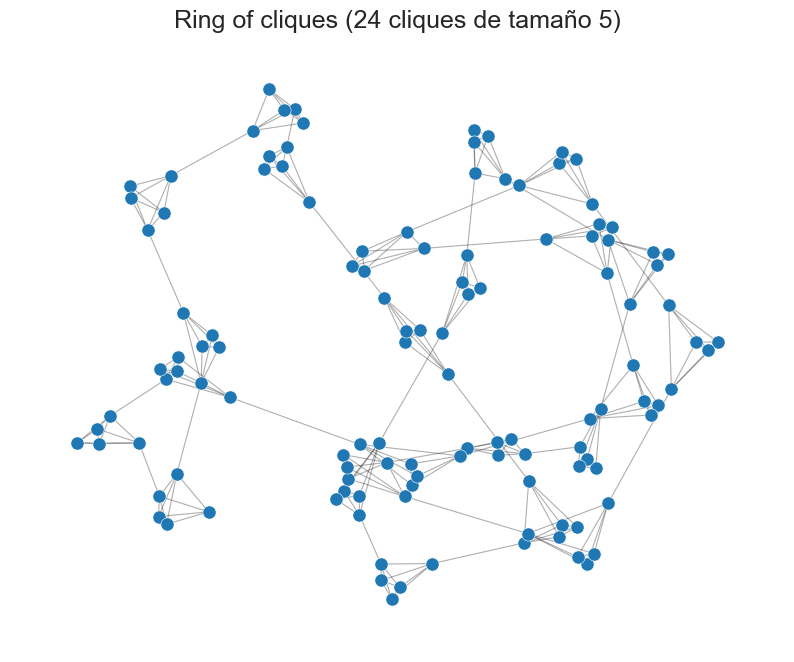

In [46]:
G_ring = nx.ring_of_cliques(24, 5)
ring_rows = []
greedy_ring = run_greedy_modularity(G_ring)
ring_rows.append({
    "method": "greedy_modularity",
    "resolution": np.nan,
    "n_communities": len(set(greedy_ring.values())),
    "modularity": partition_modularity(G_ring, greedy_ring),
})

# Plot del ring of cliques
# Cada clique idealmente debería verse como una comunidad local muy clara.

import matplotlib.pyplot as plt
import networkx as nx

G_ring = nx.ring_of_cliques(24, 5)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_ring, seed=42, k=0.2)

nx.draw_networkx_edges(G_ring, pos, alpha=0.35, width=0.8)
nx.draw_networkx_nodes(
    G_ring, pos,
    node_size=90,
    node_color="tab:blue",
    edgecolors="white",
    linewidths=0.4
)

plt.title("Ring of cliques (24 cliques de tamaño 5)")
plt.axis("off")
plt.show()



,method,resolution,n_communities,modularity
0,greedy_modularity,nan,12,0.8712
1,louvain,0.500000,24,0.8674
2,louvain,0.800000,24,0.8674
3,louvain,1.000000,13,0.8709
4,louvain,1.200000,24,0.8674
5,louvain,1.500000,24,0.8674
6,louvain,2.000000,24,0.8674
7,louvain,3.000000,24,0.8674


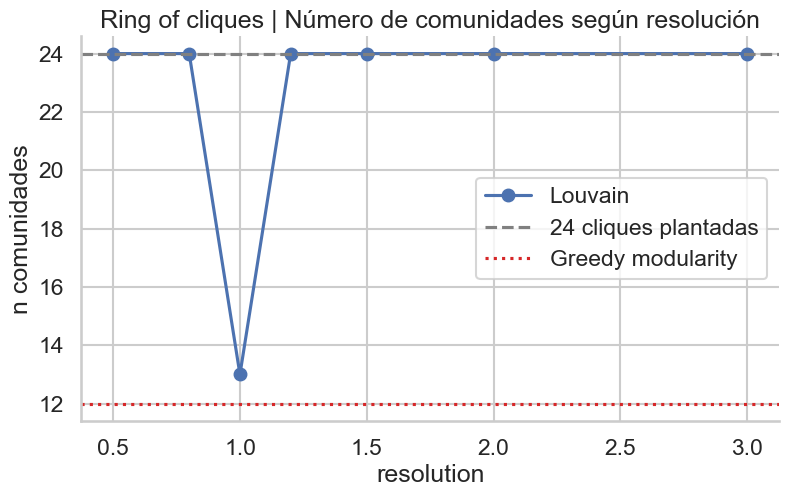

In [34]:

for gamma in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0, 3.0]:
    part = run_louvain(G_ring, seed=42, resolution=gamma, weight=None)
    ring_rows.append({
        "method": "louvain",
        "resolution": gamma,
        "n_communities": len(set(part.values())),
        "modularity": partition_modularity(G_ring, part),
    })
ring_df = pd.DataFrame(ring_rows)
display(ring_df.style.format({"modularity": "{:.4f}"}))
plt.figure(figsize=(9, 5))
lou_df = ring_df[ring_df["method"] == "louvain"].copy()
plt.plot(lou_df["resolution"], lou_df["n_communities"], marker="o", label="Louvain")
plt.axhline(24, linestyle="--", color="gray", label="24 cliques plantadas")
plt.axhline(int(ring_df.loc[ring_df["method"] == "greedy_modularity", "n_communities"].iloc[0]), linestyle=":", color="tab:red", label="Greedy modularity")
plt.title("Ring of cliques | Número de comunidades según resolución")
plt.xlabel("resolution")
plt.ylabel("n comunidades")
plt.legend()
plt.show()


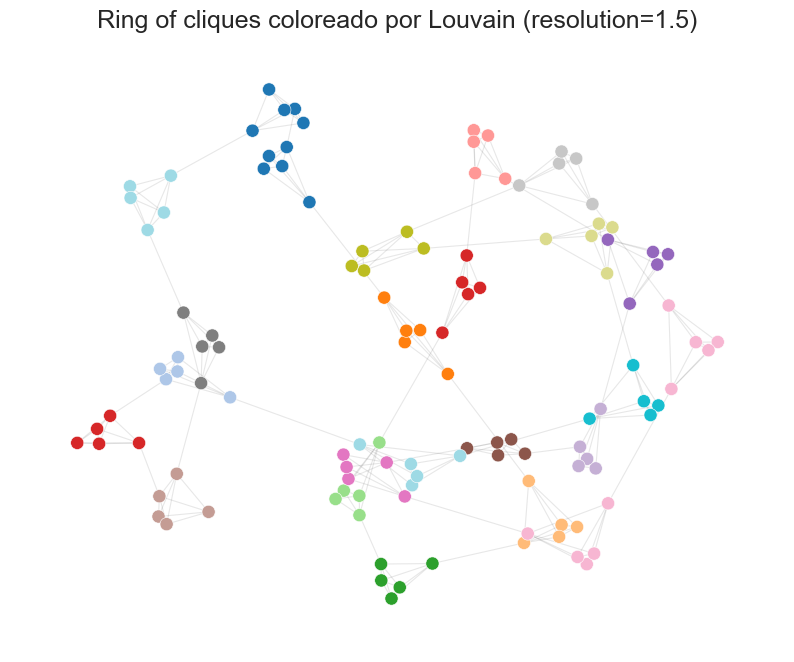

In [47]:
# plotear el ring coloreado por la partición encontrada por Louvain:

gamma = 1.5
part_ring = run_louvain(G_ring, seed=42, resolution=gamma, weight=None)

plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G_ring, seed=42, k=0.2)# posición de nodos usando spring layout para una visualización clara, con semilla fija para reproducibilidad y k ajustado para evitar solapamientos excesivos

groups = [part_ring[n] for n in G_ring.nodes()]
nx.draw_networkx_edges(G_ring, pos, alpha=0.10, width=0.8)
nx.draw_networkx_nodes(
    G_ring, pos,
    node_size=90,
    node_color=groups,
    cmap=plt.cm.tab20,
    edgecolors="white",
    linewidths=0.4
)

plt.title(f"Ring of cliques coloreado por Louvain (resolution={gamma})")
plt.axis("off")
plt.show()

### Cómo interpretamos el experimento: ring of cliques

Esta red está formada por **24 cliques de tamaño 5** conectadas en anillo. La estructura plantada es, por tanto, muy clara: idealmente esperaríamos recuperar **24 comunidades**, una por clique.

El experimento compara dos cosas:

- `greedy_modularity`, que detecta directamente una partición con alta modularidad;
- `Louvain`, variando el parámetro de resolución.

La tabla y el gráfico muestran que:

- `greedy_modularity` encuentra **12 comunidades**, es decir, fusiona varias cliques;
- `Louvain` recupera **24 comunidades** en casi todos los valores de resolución probados;
- pero en `resolution = 1.0` cae a **13 comunidades**, mostrando que la escala detectada puede cambiar sensiblemente con este parámetro.

Lo más importante es que **maximizar modularidad no siempre recupera los módulos más evidentes localmente**. Incluso en una red donde las comunidades plantadas son cliques muy claras, el criterio global puede preferir fusionarlas. Este es justamente el tipo de fenómeno asociado al **resolution limit** de la modularidad.

## 15. Core–periphery: otra lógica

Una estructura core–periphery no busca grupos separados, sino distinguir entre una zona más central y densa y una zona más periférica.

Una herramienta simple para aproximarse a esto es la **k-core decomposition**.

- El **$(k)$-core** es el subgrafo máximo que queda después de eliminar recursivamente todos los nodos con grado menor que $(k)$.
- La **coreness** de un nodo es el mayor valor de $(k)$ para el cual ese nodo todavía permanece en ese subgrafo.


### Intuición

Esto mide qué tan **profundamente incrustado** está un nodo en una zona densa de la red.

* si un nodo solo sobrevive para valores bajos de `k`, está más cerca de la periferia;
* si sobrevive hasta valores altos de `k`, está más cerca del núcleo estructural.

### Ojo importante

La `coreness` **no es** un modelo completo de core–periphery.
Lo que captura es una idea más acotada:

> qué tan internamente sostenido está un nodo por vecinos que, a su vez, también están sostenidos por otros.

Por eso es una medida útil de **embeddedness relacional**, aunque no agota toda la lógica de núcleo-periferia.



> En comunidades preguntamos “¿qué grupos hay?”. En core–periphery preguntamos “¿qué tan hacia el centro estructural está cada nodo?”.


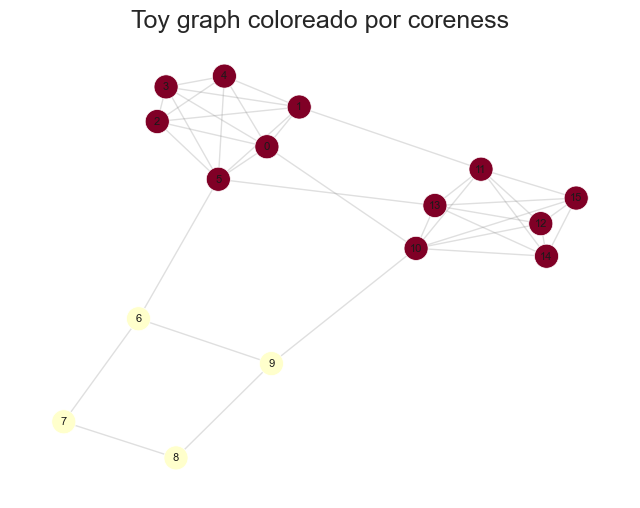

,node,core_number,degree
5,5,5,7
10,10,5,7
0,0,5,6
1,1,5,6
11,11,5,6
13,13,5,6
2,2,5,5
3,3,5,5
4,4,5,5
12,12,5,5


In [49]:
G_core = nx.barbell_graph(6, 4)
G_core.add_edges_from([(0, 10), (1, 11), (5, 13), (6, 9)])
core_num = nx.core_number(G_core)
pos_core = nx.spring_layout(G_core, seed=42)
plt.figure(figsize=(8, 6))
nodes = list(G_core.nodes())
values = [core_num[n] for n in nodes]
nx.draw_networkx_edges(G_core, pos_core, alpha=0.25, edge_color="gray")
nx.draw_networkx_nodes(
    G_core, pos_core, node_color=values, cmap=plt.cm.YlOrRd,
    node_size=300, edgecolors="white", linewidths=0.5
)
nx.draw_networkx_labels(G_core, pos_core, font_size=8)
plt.title("Toy graph coloreado por coreness")
plt.axis("off")
plt.show()
display(pd.DataFrame([{"node": n, "core_number": core_num[n], "degree": G_core.degree(n)} for n in nodes]).sort_values(
    ["core_number", "degree"], ascending=[False, False]
).head(20))


### Interpretación del ejemplo de coreness

En esta red usamos un grafo tipo **barbell**: dos cliques densas unidas por una zona intermedia más débil. Luego agregamos algunos enlaces extra entre nodos de las cliques y nodos cercanos al puente. El objetivo es mostrar que **coreness no es lo mismo que grado**, y que tampoco coincide exactamente con "estar en el centro geométrico" del dibujo.

---

### Qué significa el resultado

La figura colorea cada nodo según su **core number** o **coreness**.

Recordemos la lógica:

- un nodo tiene coreness $k$ si pertenece al $k$-core;
- el $k$-core es lo que queda después de eliminar recursivamente todos los nodos con grado menor que $k$.

Por eso, la coreness mide **qué tan profundamente incrustado está un nodo en una zona mutuamente sostenida de la red**.

---

### Qué se ve en esta red

En la tabla y en la figura aparecen dos niveles muy claros:

- los nodos de las dos zonas densas tienen **core number = 5**;
- los nodos del bloque intermedio más débil tienen una coreness más baja.

Eso tiene sentido. Las dos cliques de tamaño 6 forman regiones muy densas: aun después de hacer la poda iterativa, sus nodos siguen sosteniéndose mutuamente y sobreviven hasta un valor alto de $k$. En cambio, los nodos del puente no están tan respaldados por vecinos también densos, así que caen antes en el proceso de poda.

---

### Por qué varios nodos tienen coreness 5

Dentro de cada clique, casi todos los nodos tienen muchas conexiones con otros nodos que también están fuertemente conectados. Eso hace que sobrevivan incluso cuando exigimos un nivel alto de conectividad interna.

Por ejemplo, en la tabla:

- nodos como `0`, `1`, `5`, `10`, `11`, `13` tienen grado 6 o 7;
- otros como `2`, `3`, `4`, `12`, `14`, `15` tienen grado 5;
- pero todos aparecen con **core number = 5**.

La idea importante es que **no hace falta tener el mayor grado para tener alta coreness**. Lo que importa no es solo cuántos vecinos tiene un nodo, sino si esos vecinos también sobreviven en un subgrafo denso.

---

### Qué pasa con el puente

Los nodos del bloque intermedio conectan ambas partes de la red, pero no forman una zona tan densa. Aunque algunos de ellos pueden tener un grado razonable, no están embebidos en una región donde todos se sostienen mutuamente hasta valores altos de $k$.

Por eso:

- pueden verse “importantes” para conectar la red;
- pero tienen menor coreness que los nodos de las cliques.

Esto muestra algo clave:

> **coreness no mide puente, ni intermediación, ni centralidad global, mide embeddedness en una zona densa y mutuamente sostenida.**

---

### Diferencia entre grado y coreness

Este ejemplo sirve justamente para separar esas dos ideas.

- **Grado**: cuántos vecinos tiene un nodo.
- **Coreness**: hasta qué nivel de poda recursiva sobrevive ese nodo.

Un nodo puede tener grado alto porque conecta partes distintas de la red, pero si no está dentro de una región estructuralmente densa, su coreness no será tan alta.

En cambio, un nodo con grado algo menor puede tener coreness alta si pertenece a un núcleo muy cohesionado.

---

### Lectura conceptual

En esta red:

- las dos cliques actúan como **núcleos estructurales**;
- el bloque intermedio funciona más como **zona de enlace** o **región periférica relativa**;
- la coreness distingue bien esas dos lógicas.

Entonces, el resultado ilustra bien que la descomposición en $k$-cores sirve para identificar **qué nodos están realmente metidos dentro del núcleo denso de la red**, y no simplemente cuáles tienen muchas conexiones o cuáles están visualmente en el medio del dibujo.

---

### Idea final

> La coreness no pregunta solo "cuántos vecinos tiene este nodo", sino "¿sobrevive cuando empezamos a eliminar recursivamente los nodos menos sostenidos?". En este ejemplo, las cliques sobreviven como núcleo denso, mientras que el puente cae antes.

## 16. Roles estructurales

Rol estructural no es comunidad ni núcleo. Es una forma de describir qué hace un nodo en la topología.

La literatura clásica distingue:

- **equivalencia estructural**: patrones de vecindad muy similares;
- **equivalencia regular**: posiciones parecidas aunque no compartan exactamente los mismos vecinos.

En práctica aplicada, sin construir un blockmodel completo, se puede aproximar roles combinando:

- comunidad;
- `core_number`;
- betweenness;
- fuerza/grado;
- participación entre comunidades.


## 17. Aplicación a compras públicas: qué cambia

En compras públicas, muchas redes naturales son bipartitas:

- empresa–licitación;
- empresa–organismo.

Si proyectamos a proveedor–proveedor o comprador–comprador, estamos creando una nueva red derivada. Entonces hay tres decisiones analíticas distintas:

1. qué algoritmo usar;
2. qué grafo construir antes de correrlo;
3. qué interpretación sustantiva es defendible sin over-claim.

La misma estructura puede verse de forma distinta según si trabajamos en:

- la red bipartita original, donde preservamos la relación primaria empresa–proceso u organismo;
- una proyección proveedor–proveedor, donde enfatizamos co-participación o solapamiento competitivo;
- una proyección organismo–organismo, donde enfatizamos similitud de demanda o patrones de compra.

Por eso, en este contexto, detectar mesoestructura nunca es solo “aplicar un algoritmo”: es una decisión conjunta entre representación, métrica y lectura sustantiva.


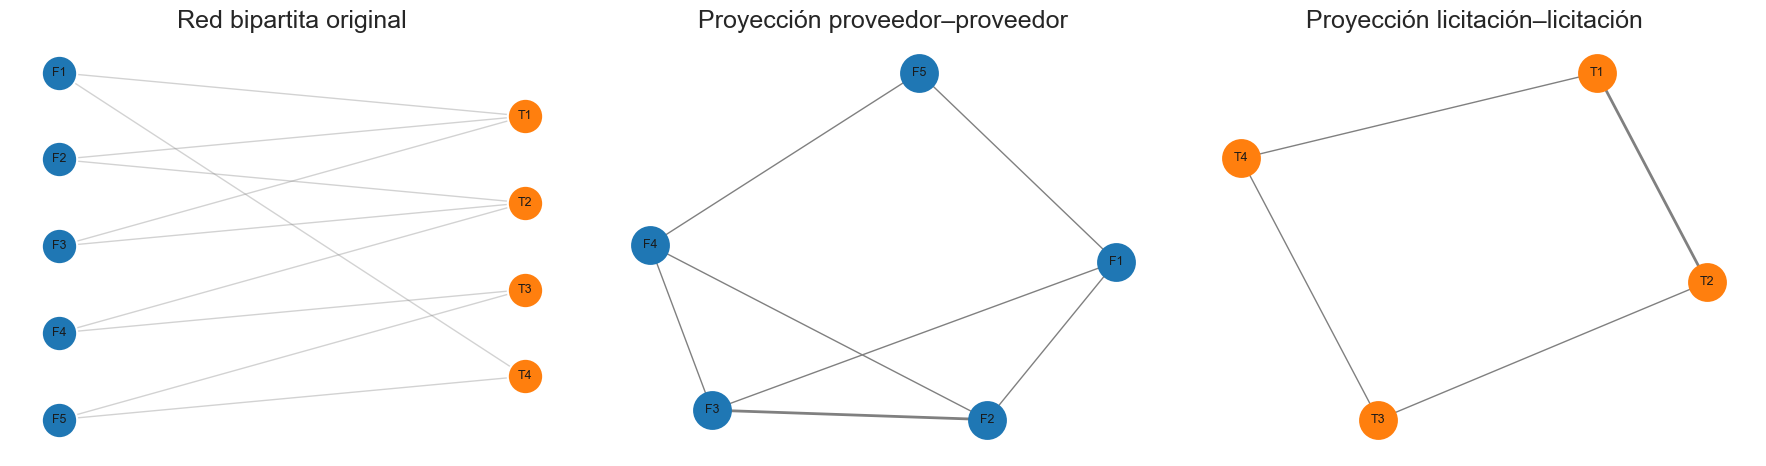

In [52]:
B = nx.Graph()
firms = ["F1", "F2", "F3", "F4", "F5"]
tenders = ["T1", "T2", "T3", "T4"]
B.add_nodes_from(firms, bipartite="firm")
B.add_nodes_from(tenders, bipartite="tender")
B.add_edges_from([
    ("F1", "T1"), ("F2", "T1"), ("F3", "T1"),
    ("F2", "T2"), ("F3", "T2"), ("F4", "T2"),
    ("F4", "T3"), ("F5", "T3"),
    ("F1", "T4"), ("F5", "T4"),
])
supplier_proj = nx.bipartite.weighted_projected_graph(B, firms)
buyer_proj = nx.bipartite.weighted_projected_graph(B, tenders)
pos_b = {}
for i, f in enumerate(firms):
    pos_b[f] = (0, len(firms) - i)
for i, t in enumerate(tenders):
    pos_b[t] = (1, len(tenders) - i + 0.5)
pos_s = nx.spring_layout(supplier_proj, seed=42, weight="weight")
pos_t = nx.spring_layout(buyer_proj, seed=42, weight="weight")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
nx.draw_networkx_edges(B, pos_b, ax=axes[0], alpha=0.35, edge_color="gray")
nx.draw_networkx_nodes(B, pos_b, nodelist=firms, node_color="#1f77b4", node_size=650, ax=axes[0], edgecolors="white")
nx.draw_networkx_nodes(B, pos_b, nodelist=tenders, node_color="#ff7f0e", node_size=650, ax=axes[0], edgecolors="white")
nx.draw_networkx_labels(B, pos_b, ax=axes[0], font_size=9)
axes[0].set_title("Red bipartita original")
axes[0].axis("off")
nx.draw_networkx(supplier_proj, pos_s, ax=axes[1], node_color="#1f77b4", edge_color="gray", node_size=700, width=[supplier_proj[u][v]["weight"] for u,v in supplier_proj.edges()], font_size=9)
axes[1].set_title("Proyección proveedor–proveedor")
axes[1].axis("off")
nx.draw_networkx(buyer_proj, pos_t, ax=axes[2], node_color="#ff7f0e", edge_color="gray", node_size=700, width=[buyer_proj[u][v]["weight"] for u,v in buyer_proj.edges()], font_size=9)
axes[2].set_title("Proyección licitación–licitación")
axes[2].axis("off")
plt.tight_layout()
plt.show()


## 18. Qué puede significar una comunidad en compras públicas

Según la representación elegida, una comunidad podría sugerir:

- nichos de proveedores que compiten recurrentemente en un subconjunto del mercado;
- clusters de organismos con patrones de contratación similares;
- módulos territoriales o sectoriales;
- subconjuntos del mercado con especialización temática;
- dependencias institucionales sobre un subconjunto relativamente estable de proveedores;
- segmentaciones proveedor–mercado que pueden ser analíticamente accionables.

Traducción aplicada posible:

- un módulo de proveedores puede leerse como un **segmento competitivo**;
- un módulo de organismos puede leerse como un **segmento de demanda**;
- un módulo mixto asociado a ciertos rubros o territorios puede sugerir especialización, barreras de entrada o baja contestabilidad (competencia es poco disputable o poco abierta).

Pero eso sigue siendo una **hipótesis sustantiva**, no una conclusión automática. La validación requiere metadatos externos: rubro, territorio, tamaño de contratos, tipo de organismo y trayectoria temporal.


## 19. Qué puede sugerir un core y qué pueden sugerir roles

Un núcleo de alta `coreness` podría sugerir:

- proveedores generalistas con presencia transversal en múltiples segmentos;
- organismos articuladores con fuerte inserción en la estructura de contratación;
- actores con alta embeddedness en la red y cobertura sostenida del mercado.

En clave aplicada, eso puede traducirse en preguntas sobre:

- cobertura transversal del mercado por ciertos proveedores;
- dependencia institucional de algunos organismos respecto de un subconjunto reducido de oferentes;
- resiliencia o vulnerabilidad de segmentos del mercado si ciertos actores salen.

Los roles estructurales podrían sugerir:

- puentes entre rubros o territorios;
- hubs locales;
- periféricos especializados;
- nodos frontera;
- actores redundantes o de baja diferenciación.

La lectura correcta no es “este nodo es importante” en abstracto, sino “este nodo ocupa una posición que puede afectar segmentación, dependencia o circulación entre segmentos”.


## 20. Riesgos metodológicos clave

- Una partición algorítmica no equivale automáticamente a una comunidad real.
- La proyección bipartita pierde información y puede inflar enlaces.
- Alta modularidad no implica mecanismo causal.
- Alta modularidad tampoco implica, por sí sola, colusión, captura o segmentación “verdadera”.
- La mesoestructura depende de la definición del grafo, pesos, umbrales y ventana temporal.
- `k-core` es una aproximación útil, no un modelo completo de core–periphery.
- Los roles derivados de métricas simples son etiquetas heurísticas, no tipos ontológicos (categorías que asumimos como si existieran realmente en el mundo, de manera objetiva y estable; no confundir una etiqueta útil para describir un patrón con una esencia real del actor).
- Si no hay validación con metadata externa, la interpretación debe permanecer en nivel de hipótesis.

Pregunta disciplinante para clase:

**¿Qué parte de mi hallazgo proviene de la red observada y qué parte proviene de mis decisiones de modelamiento?**


## 21. Checklist final para análisis 

1. ¿Qué grafo estoy analizando exactamente?
2. ¿Qué parte del resultado depende de la representación elegida?
3. ¿Qué algoritmo usé y qué definición de comunidad está codificando?
4. ¿Qué tan estable es la partición entre múltiples `seeds`?
5. ¿Qué cambia al variar resolución, pesos o umbrales?
6. ¿Qué dice `k-core` y qué no dice sobre núcleo–periferia?
7. ¿Qué lectura de roles es razonable y cuál sería excesiva?
8. ¿Qué interpretación aplicada es plausible en compras públicas y cuál sería over-claiming?
9. ¿Con qué metadata externa voy a validar esta lectura?
